# RUN 1:
  "N" : 10,
    "K" : 2,
    "B_train" : 50,
    "B_test" : 100, 
    "tau" : 0.2,
    "sigma_u" : 1.0,  
    "warmup_steps" : 100,
    "num_samples" : 150,
    "target_accept_prob" : 0.75,
    "seed" : 42

In [1]:
%load_ext autoreload
%autoreload 2

params = {
    "N" : 10,
    "K" : 2,
    "B_train" : 50,
    "B_test" : 100, 
    "tau" : 0.2,
    "sigma_u" : 1.0,  
    "warmup_steps" : 100,
    "num_samples" : 150,
    "target_accept_prob" : 0.75,
    "seed" : 42
}
import torch
import numpy as np
import pyro
import pyro.infer as infer
from pyro.infer import MCMC, NUTS

def enforce_reproducibility(seed):
    np.random.seed(seed)
    torch.manual_seed(seed)
    pyro.clear_param_store()
    pyro.set_rng_seed(seed)

enforce_reproducibility(params["seed"])
print(f"✅ Workspace locked. Ready for configuration setup.")

✅ Workspace locked. Ready for configuration setup.


In [2]:
import sys
!{sys.executable} -m pip install arviz

In [3]:
import os
import sys
import arviz as az
#current folder path
current_notebook_dir = os.getcwd()
#find parent folder one level up
project_root_dir = os.path.abspath(os.path.join(current_notebook_dir, ".."))
if project_root_dir not in sys.path:
    sys.path.append(project_root_dir)
    print(f"Successfully added project root to path: {project_root_dir}")

from src.model import PhylogeneticPrior
from src.diagnostics import (
    evaluate_test_diagnostics,
    print_diagnostic_report,
    compute_nj_residual
)
from src.penalty import get_fresh_test_quartets


Successfully added project root to path: /Users/riyaaggarwal/Desktop/Block4/Block4 project/scripts/implementation


In [4]:
#guassian prior
# prior model represents the base object, the framework
prior_model = PhylogeneticPrior(
    N= params ["N"],
    K=params ["K"],
    B= params["B_train"],
    sigma_u=params["sigma_u"],
    seed = params["seed"]
)
print("Prior model parameters are:", prior_model)

#fresh test quartets for validation from function in penalty file
test_quartets = get_fresh_test_quartets(
    N= params ["N"],
    B_test = params["B_test"],
    train_quartets=prior_model.fixed_indices,
    seed = 123
)




Prior model parameters are: <src.model.PhylogeneticPrior object at 0x1253e3ad0>


In [5]:
#lambda grid for test run
lambda_grid = [0.0, 0.1, 0.5,1.0, 2.5, 5.0]
results ={} #dictionary to store results

### Running the diagnostics on test data

In [12]:
#Running test run , for every value of lambda in the grid
for lmbda in lambda_grid:
    print(f" EXPERIMENT RUN: λ4 = {lmbda} (N={params['N']})")

    # conditioned model is the model with specific hyperparameters
    # creates specific model instance 
    def model_conditioned(current_lmbda=lmbda):
        """this model returns specific model instance with value of hyperparameters."""
        return prior_model.initialize(
            lmbda_4 = current_lmbda,
            lmbda_g = 0.0,
            tau= params ["tau"],
            use_scale= False #to isolate lambda sweep
        )
    
    enforce_reproducibility(params["seed"])

    #building NUTS engine
    nuts_kernel = NUTS(model_conditioned, adapt_step_size=True, target_accept_prob=params["target_accept_prob"] )
    mcmc =  MCMC(
        kernel = nuts_kernel,
        num_samples= params["num_samples"],
        warmup_steps=params["warmup_steps"],
        num_chains= 1
    )

    #running chains
    mcmc.run()


    #arviz diagnostics
    print("📊 Calculating ArviZ MCMC convergence diagnostics...")
    # Convert the Pyro MCMC object into an ArviZ InferenceData container
    idata = az.from_pyro(mcmc)
    
    # Calculate summary stats (R-hat and Effective Sample Size) specifically for latent coordinate 'u'
    summary_stats = az.summary(idata, var_names=["u"])
    
    # Extract structural summaries to evaluate chain mixing quality
    mean_rhat = summary_stats["r_hat"].mean()
    min_ess_bulk = summary_stats["ess_bulk"].min()
    
    print(f"  └─ Mean R-hat (Target ≤ 1.05): {mean_rhat:.4f}")
    print(f"  └─ Minimum Bulk ESS (Higher is better): {min_ess_bulk:.1f}")

    posterior_samples = mcmc.get_samples()
    
    #we only got posterior samples : latent points, not their distance matrices yet
    D_samples_list = []
    print(f"DEBUG: Confirmed D_samples shape is: {D_samples.shape}")

    #we get 150 samples as we asked- coordinates of these 150 samples
    #posterior samples : [150,10,2] i.e. total 150 samples, for 10 taxa and 2 dimensions
    #checking no of samples collected by MCMC
    num_samples_collected = posterior_samples[next(iter(posterior_samples))].shape[0]
 
    for s in range(num_samples_collected):
        single_sample = {k: v[s:s+1] for k, v in posterior_samples.items()} 
        try:
            # Replay each individual sample configuration separately
            predictive = infer.Predictive(model_conditioned, posterior_samples=single_sample)
            single_pred = predictive()
            D_matrix = single_pred["D_tilde"].squeeze(0)
            
            if torch.isnan(D_matrix).any() or torch.isinf(D_matrix).any():
                continue
                
            D_samples_list.append(D_matrix.detach().cpu().numpy())
        except Exception:
            continue

    if len(D_samples_list) == 0:
        print(f"❌ Landscape Failure: Complete numerical overflow at λ4 = {lmbda}")
        results[lmbda] = {"metrics": None, "mean_nj_residual": np.nan, "divergences": "ALL"}
        continue
        
    D_samples = torch.stack([
        torch.as_tensor(d, dtype=torch.float32).reshape(10, 10) 
        for d in D_samples_list
    ])


    # Run your real post-hoc diagnostics from your src modules
    print(f"📊 Analyzing {D_samples.shape[0]} stable sample distance representations...")
    metrics = evaluate_test_diagnostics(D_samples, test_quartets, epsilon=0.05, gamma=0.05)
    print_diagnostic_report(metrics, epsilon=0.05, gamma=0.05)
    
    nj_residuals = [compute_nj_residual(D_samples[i]) for i in range(D_samples.shape[0])]
    mean_nj_residual = np.mean(nj_residuals)
    print(f"  └─ Post-hoc Mean NJ Tree Residual R_NJ(D~): {mean_nj_residual * 100:.3f}%")
    
    # Safely archive all elements together
    results[lmbda] = {
        "metrics": metrics,
        "mean_nj_residual": mean_nj_residual,
        "divergences": mcmc.diagnostics().get("divergences", {}).get("chain 0", 0),
        "arviz_summary": summary_stats,
        "mean_rhat": mean_rhat,
        "min_ess": min_ess_bulk
    }


 EXPERIMENT RUN: λ4 = 0.0 (N=10)


Sample: 100%|██████████| 250/250 [00:01, 144.55it/s, step size=7.30e-01, acc. prob=0.848]
/Users/riyaaggarwal/miniforge3/envs/clean_mcmc_env/lib/python3.11/site-packages/arviz/data/io_pyro.py:158: UserWarning: Could not get vectorized trace, log_likelihood group will be omitted. Check your model vectorization or set log_likelihood=False
  warnings.warn(
arviz - WARNING - Shape validation failed: input_shape: (1, 150), minimum_shape: (chains=2, draws=4)


📊 Calculating ArviZ MCMC convergence diagnostics...
  └─ Mean R-hat (Target ≤ 1.05): nan
  └─ Minimum Bulk ESS (Higher is better): 110.0
DEBUG: Confirmed D_samples shape is: torch.Size([150, 10, 10])
📊 Analyzing 150 stable sample distance representations...

[1] Hard Four-Point Violations v_q(D~):
  └─ Median Violation        : 0.0872
  └─ 95th Percentile (q_0.95): 0.2654
  └─ 99th Percentile         : 0.3352

[2] Approx Tree-Consistency Rate A(D~; ε=0.05):
  └─ Fraction Consistent     : 34.13%

[3] Quartet Gap Diagnostics g_q(D~):
  └─ Median Branch Gap       : 0.3898
  └─ 5th Percentile Gap      : 0.0351
  └─ Star-like Fraction (≤γ) : 7.39%

[4] Normalized Distance-Scale Diagnostics (Expect Mean=1.0):
  └─ Minimum Pairwise Dist   : 0.0172
  └─ Median Pairwise Dist    : 0.9900
  └─ Maximum Pairwise Dist   : 2.8486

  └─ Post-hoc Mean NJ Tree Residual R_NJ(D~): 61.172%
 EXPERIMENT RUN: λ4 = 0.1 (N=10)


Sample: 100%|██████████| 250/250 [00:04, 59.92it/s, step size=4.23e-01, acc. prob=0.884]
/Users/riyaaggarwal/miniforge3/envs/clean_mcmc_env/lib/python3.11/site-packages/arviz/data/io_pyro.py:158: UserWarning: Could not get vectorized trace, log_likelihood group will be omitted. Check your model vectorization or set log_likelihood=False
  warnings.warn(
arviz - WARNING - Shape validation failed: input_shape: (1, 150), minimum_shape: (chains=2, draws=4)


📊 Calculating ArviZ MCMC convergence diagnostics...
  └─ Mean R-hat (Target ≤ 1.05): nan
  └─ Minimum Bulk ESS (Higher is better): 74.0
DEBUG: Confirmed D_samples shape is: torch.Size([150, 10, 10])
📊 Analyzing 150 stable sample distance representations...

[1] Hard Four-Point Violations v_q(D~):
  └─ Median Violation        : 0.0845
  └─ 95th Percentile (q_0.95): 0.2689
  └─ 99th Percentile         : 0.3284

[2] Approx Tree-Consistency Rate A(D~; ε=0.05):
  └─ Fraction Consistent     : 33.97%

[3] Quartet Gap Diagnostics g_q(D~):
  └─ Median Branch Gap       : 0.3710
  └─ 5th Percentile Gap      : 0.0290
  └─ Star-like Fraction (≤γ) : 8.55%

[4] Normalized Distance-Scale Diagnostics (Expect Mean=1.0):
  └─ Minimum Pairwise Dist   : 0.0200
  └─ Median Pairwise Dist    : 0.9767
  └─ Maximum Pairwise Dist   : 3.0151

  └─ Post-hoc Mean NJ Tree Residual R_NJ(D~): 58.679%
 EXPERIMENT RUN: λ4 = 0.5 (N=10)


...

📊 Calculating ArviZ MCMC convergence diagnostics...
  └─ Mean R-hat (Target ≤ 1.05): nan
  └─ Minimum Bulk ESS (Higher is better): 81.0
DEBUG: Confirmed D_samples shape is: torch.Size([150, 10, 10])
📊 Analyzing 150 stable sample distance representations...

[1] Hard Four-Point Violations v_q(D~):
  └─ Median Violation        : 0.0835
  └─ 95th Percentile (q_0.95): 0.2510
  └─ 99th Percentile         : 0.3051

[2] Approx Tree-Consistency Rate A(D~; ε=0.05):
  └─ Fraction Consistent     : 34.23%

[3] Quartet Gap Diagnostics g_q(D~):
  └─ Median Branch Gap       : 0.3024
  └─ 5th Percentile Gap      : 0.0249
  └─ Star-like Fraction (≤γ) : 10.11%

[4] Normalized Distance-Scale Diagnostics (Expect Mean=1.0):
  └─ Minimum Pairwise Dist   : 0.0231
  └─ Median Pairwise Dist    : 0.9672
  └─ Maximum Pairwise Dist   : 2.7389

  └─ Post-hoc Mean NJ Tree Residual R_NJ(D~): 49.990%
 EXPERIMENT RUN: λ4 = 2.5 (N=10)


Sample: 100%|██████████| 250/250 [00:12, 20.13it/s, step size=1.43e-01, acc. prob=0.805]
/Users/riyaaggarwal/miniforge3/envs/clean_mcmc_env/lib/python3.11/site-packages/arviz/data/io_pyro.py:158: UserWarning: Could not get vectorized trace, log_likelihood group will be omitted. Check your model vectorization or set log_likelihood=False
  warnings.warn(
arviz - WARNING - Shape validation failed: input_shape: (1, 150), minimum_shape: (chains=2, draws=4)


📊 Calculating ArviZ MCMC convergence diagnostics...
  └─ Mean R-hat (Target ≤ 1.05): nan
  └─ Minimum Bulk ESS (Higher is better): 67.0
DEBUG: Confirmed D_samples shape is: torch.Size([150, 10, 10])
📊 Analyzing 150 stable sample distance representations...

[1] Hard Four-Point Violations v_q(D~):
  └─ Median Violation        : 0.0837
  └─ 95th Percentile (q_0.95): 0.2250
  └─ 99th Percentile         : 0.2785

[2] Approx Tree-Consistency Rate A(D~; ε=0.05):
  └─ Fraction Consistent     : 33.61%

[3] Quartet Gap Diagnostics g_q(D~):
  └─ Median Branch Gap       : 0.2523
  └─ 5th Percentile Gap      : 0.0217
  └─ Star-like Fraction (≤γ) : 11.30%

[4] Normalized Distance-Scale Diagnostics (Expect Mean=1.0):
  └─ Minimum Pairwise Dist   : 0.0127
  └─ Median Pairwise Dist    : 0.9685
  └─ Maximum Pairwise Dist   : 3.5555

  └─ Post-hoc Mean NJ Tree Residual R_NJ(D~): 43.261%
 EXPERIMENT RUN: λ4 = 5.0 (N=10)


Sample: 100%|██████████| 250/250 [00:17, 13.92it/s, step size=8.83e-02, acc. prob=0.822]
/Users/riyaaggarwal/miniforge3/envs/clean_mcmc_env/lib/python3.11/site-packages/arviz/data/io_pyro.py:158: UserWarning: Could not get vectorized trace, log_likelihood group will be omitted. Check your model vectorization or set log_likelihood=False
  warnings.warn(
arviz - WARNING - Shape validation failed: input_shape: (1, 150), minimum_shape: (chains=2, draws=4)


📊 Calculating ArviZ MCMC convergence diagnostics...
  └─ Mean R-hat (Target ≤ 1.05): nan
  └─ Minimum Bulk ESS (Higher is better): 38.0
DEBUG: Confirmed D_samples shape is: torch.Size([150, 10, 10])
📊 Analyzing 150 stable sample distance representations...

[1] Hard Four-Point Violations v_q(D~):
  └─ Median Violation        : 0.0652
  └─ 95th Percentile (q_0.95): 0.2091
  └─ 99th Percentile         : 0.2648

[2] Approx Tree-Consistency Rate A(D~; ε=0.05):
  └─ Fraction Consistent     : 40.90%

[3] Quartet Gap Diagnostics g_q(D~):
  └─ Median Branch Gap       : 0.1931
  └─ 5th Percentile Gap      : 0.0170
  └─ Star-like Fraction (≤γ) : 15.13%

[4] Normalized Distance-Scale Diagnostics (Expect Mean=1.0):
  └─ Minimum Pairwise Dist   : 0.0026
  └─ Median Pairwise Dist    : 0.9741
  └─ Maximum Pairwise Dist   : 3.3336

  └─ Post-hoc Mean NJ Tree Residual R_NJ(D~): 36.763%


In [13]:
import pandas as pd

# Initialize a list to hold the row data
table_rows = []

# Loop through each lambda value and extract archived metrics
for lmbda, res in results.items():
    # Handle possible landscape failure / skipped runs safely
    if res["metrics"] is None:
        table_rows.append({
            "Lambda_4": lmbda,
            "q_0.95 Violations": "OVERFLOW",
            "Mean NJ Residual (%)": "OVERFLOW",
            "Mean R-hat": "N/A",
            "Min Bulk ESS": "N/A",
            "Divergences": res.get("divergences", "ALL")
        })
        continue
        
    # Extract the 95th quantile of hard violations from your custom metrics structure
    try:
        q95 = res["metrics"]["hard_violations"]["quantile_95"]
    except (KeyError, TypeError):
        q95 = float("nan")
        
    # Append all compiled metrics for this specific grid point
    table_rows.append({
        "Lambda_4": lmbda,
        "q_0.95 Violations": round(float(q95), 4) if not pd.isna(q95) else "N/A",
        "Mean NJ Residual (%)": round(float(res["mean_nj_residual"] * 100), 2),
        "Mean R-hat": round(float(res["mean_rhat"]), 4),
        "Min Bulk ESS": round(float(res["min_ess"]), 1),
        "Divergences": res["divergences"]
    })

# Convert the list of dictionaries into a structured DataFrame
df_summary = pd.DataFrame(table_rows)

# Display the polished markdown table
print("📊 EXPERIMENT 1 REGULARIZATION MATRIX (N=10 Baseline Summary) TEST DATA")
display(df_summary)

📊 EXPERIMENT 1 REGULARIZATION MATRIX (N=10 Baseline Summary) TEST DATA


,Lambda_4,q_0.95 Violations,Mean NJ Residual (%),Mean R-hat,Min Bulk ESS,Divergences
0,0.0,0.2654,61.17,NaN,110.0,[]
1,0.1,0.2689,58.68,NaN,74.0,[]
2,0.5,0.2531,54.28,NaN,132.0,[]
3,1.0,0.2510,49.99,NaN,81.0,[]
4,2.5,0.2250,43.26,NaN,67.0,[]
5,5.0,0.2091,36.76,NaN,38.0,[]


### Plot

In [14]:
import sys
!{sys.executable} -m pip install seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)


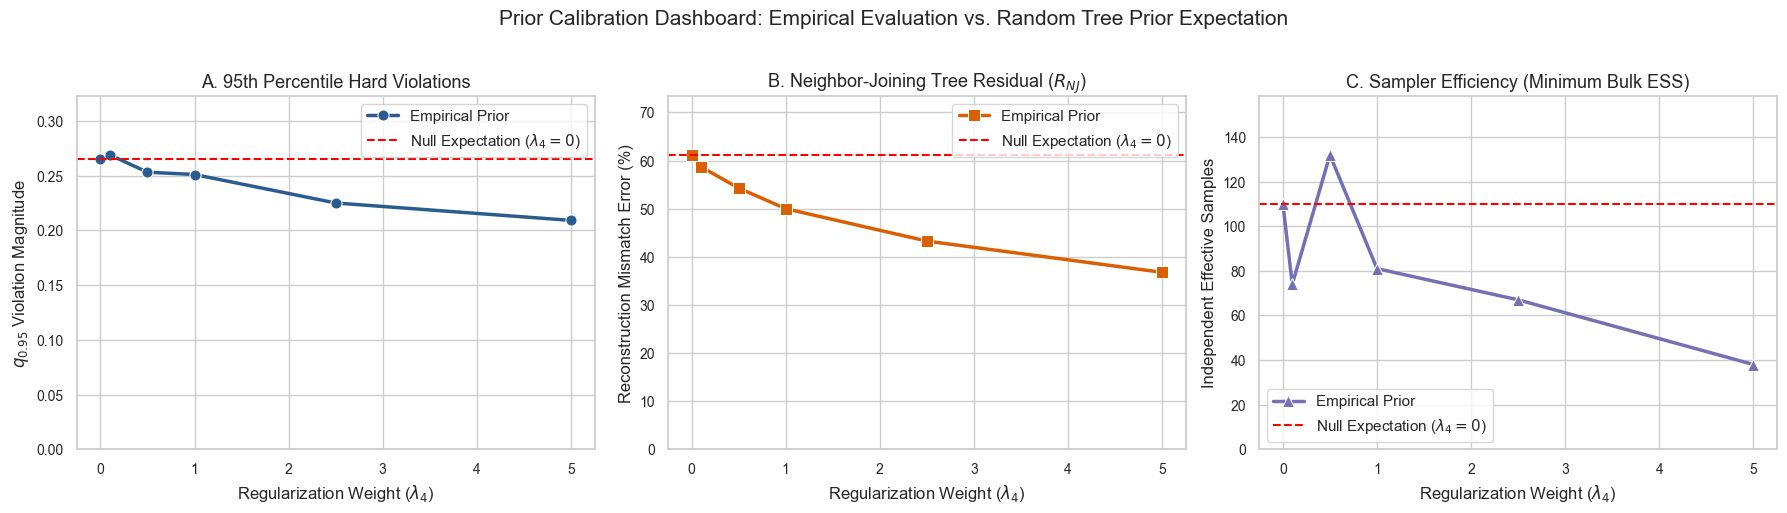

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Extract and sort grid data arrays safely from your active results dictionary
lambdas = sorted(list(results.keys()))
q95_violations = [results[l]["metrics"]["hard_violations"]["quantile_95"] for l in lambdas]
nj_residuals = [results[l]["mean_nj_residual"] * 100 for l in lambdas]
min_ess = [results[l]["min_ess"] for l in lambdas]

# 2. Define the Null Expectations (the baseline values when Lambda_4 = 0.0)
null_q95 = q95_violations[lambdas.index(0.0)]
null_nj = nj_residuals[lambdas.index(0.0)]
null_ess = min_ess[lambdas.index(0.0)]

# Establish design guidelines for publication clarity
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    "font.size": 11,
    "axes.labelsize": 12,
    "axes.titlesize": 13,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "figure.titlesize": 15
})

# Create a 1x3 dashboard layout panel
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=False)
fig.suptitle("Prior Calibration Dashboard: Empirical Evaluation vs. Random Tree Prior Expectation", y=1.02)

# --- PANEL A: Hard Four-Point Condition Violations ---
sns.lineplot(x=lambdas, y=q95_violations, ax=axes[0], marker="o", color="#2b5c8f", linewidth=2.5, markersize=8, label="Empirical Prior")
axes[0].axhline(y=null_q95, color="red", linestyle="--", linewidth=1.5, label="Null Expectation ($\lambda_4=0$)")
axes[0].set_title("A. 95th Percentile Hard Violations")
axes[0].set_xlabel("Regularization Weight ($\lambda_4$)")
axes[0].set_ylabel("$q_{0.95}$ Violation Magnitude")
axes[0].set_ylim(0, max(q95_violations) * 1.2)
axes[0].legend(loc="upper right")

# --- PANEL B: Neighbor-Joining Tree Projection Residual ---
sns.lineplot(x=lambdas, y=nj_residuals, ax=axes[1], marker="s", color="#d95f02", linewidth=2.5, markersize=8, label="Empirical Prior")
axes[1].axhline(y=null_nj, color="red", linestyle="--", linewidth=1.5, label="Null Expectation ($\lambda_4=0$)")
axes[1].set_title("B. Neighbor-Joining Tree Residual ($R_{NJ}$)")
axes[1].set_xlabel("Regularization Weight ($\lambda_4$)")
axes[1].set_ylabel("Reconstruction Mismatch Error (%)")
axes[1].set_ylim(0, max(nj_residuals) * 1.2)
axes[1].legend(loc="upper right")

# --- PANEL C: NUTS Chain Sampling Efficiency ---
sns.lineplot(x=lambdas, y=min_ess, ax=axes[2], marker="^", color="#7570b3", linewidth=2.5, markersize=8, label="Empirical Prior")
axes[2].axhline(y=null_ess, color="red", linestyle="--", linewidth=1.5, label="Null Expectation ($\lambda_4=0$)")
axes[2].set_title("C. Sampler Efficiency (Minimum Bulk ESS)")
axes[2].set_xlabel("Regularization Weight ($\lambda_4$)")
axes[2].set_ylabel("Independent Effective Samples")
axes[2].set_ylim(0, max(min_ess) * 1.2)
axes[2].legend(loc="lower left")

# Optimize space layout bounding box margins
plt.tight_layout()

# Save a high-resolution version directly to your disk for tomorrow's slides
plt.savefig("prior_calibration_expectation_dashboard.png", dpi=300, bbox_inches="tight")
plt.show()

The values are expected to drop to 0. 

For further runs, we tweak the parameters


# RUN 2:



In [18]:
#clear old Pyro parameter traces and reset the seeds fresh
pyro.clear_param_store()
enforce_reproducibility(42)


params = {
    "N" : 10,
    "K" : 2,
    "B_train" : 50,
    "B_test" : 100, 
    "tau" : 0.05,   # <-----
    "sigma_u" : 1.0,  
    "warmup_steps" : 200, # <-----
    "num_samples" : 300,  # <-----
    "target_accept_prob" : 0.85,
    "seed" : 42
}

#guassian prior
# prior model represents the base object, the framework
prior_model = PhylogeneticPrior(
    N= params ["N"],
    K=params ["K"],
    B= params["B_train"],
    sigma_u=params["sigma_u"],
    seed = params["seed"]
)
print("Prior model parameters are:", prior_model)

#fresh test quartets for validation from function in penalty file
test_quartets = get_fresh_test_quartets(
    N= params ["N"],
    B_test = params["B_test"],
    train_quartets=prior_model.fixed_indices,
    seed = 123
)

#lambda grid for test run
lambda_grid = [0.0, 1.0, 10.0, 50.0, 100.0, 250.0] #<-----
results_exp2 = {}


Prior model parameters are: <src.model.PhylogeneticPrior object at 0x137122a10>


In [20]:
#Running test run , for every value of lambda in the grid
for lmbda in lambda_grid:
    print(f" EXPERIMENT RUN 2: λ4 = {lmbda} (N={params['N']})")

    # conditioned model is the model with specific hyperparameters
    # creates specific model instance 
    def model_conditioned(current_lmbda=lmbda):
        """this model returns specific model instance with value of hyperparameters."""
        return prior_model.initialize(
            lmbda_4 = current_lmbda,
            lmbda_g = 0.0,
            tau= params ["tau"],
            use_scale= False #to isolate lambda sweep
        )
    
    enforce_reproducibility(params["seed"])

    #building NUTS engine
    nuts_kernel = NUTS(model_conditioned, adapt_step_size=True, target_accept_prob=params["target_accept_prob"] )
    mcmc =  MCMC(
        kernel = nuts_kernel,
        num_samples= params["num_samples"],
        warmup_steps=params["warmup_steps"],
        num_chains= 1
    )

    #running chains
    mcmc.run()


    #arviz diagnostics
    print("📊 Calculating ArviZ MCMC convergence diagnostics...")
    # Convert the Pyro MCMC object into an ArviZ InferenceData container
    idata = az.from_pyro(mcmc)
    
    # Calculate summary stats (R-hat and Effective Sample Size) specifically for latent coordinate 'u'
    summary_stats = az.summary(idata, var_names=["u"])
    
    # Extract structural summaries to evaluate chain mixing quality
    mean_rhat = summary_stats["r_hat"].mean()
    min_ess_bulk = summary_stats["ess_bulk"].min()
    
    print(f"  └─ Mean R-hat (Target ≤ 1.05): {mean_rhat:.4f}")
    print(f"  └─ Minimum Bulk ESS (Higher is better): {min_ess_bulk:.1f}")

    posterior_samples = mcmc.get_samples()
    
    #we only got posterior samples : latent points, not their distance matrices yet
    D_samples_list = []
    print(f"DEBUG: Confirmed D_samples shape is: {D_samples.shape}")

    #we get 150 samples as we asked- coordinates of these 150 samples
    #posterior samples : [150,10,2] i.e. total 150 samples, for 10 taxa and 2 dimensions
    #checking no of samples collected by MCMC
    num_samples_collected = posterior_samples[next(iter(posterior_samples))].shape[0]
 
    for s in range(num_samples_collected):
        single_sample = {k: v[s:s+1] for k, v in posterior_samples.items()} 
        try:
            # Replay each individual sample configuration separately
            predictive = infer.Predictive(model_conditioned, posterior_samples=single_sample)
            single_pred = predictive()
            D_matrix = single_pred["D_tilde"].squeeze(0)
            
            if torch.isnan(D_matrix).any() or torch.isinf(D_matrix).any():
                continue
                
            D_samples_list.append(D_matrix.detach().cpu().numpy())
        except Exception:
            continue

    if len(D_samples_list) == 0:
        print(f"❌ Landscape Failure: Complete numerical overflow at λ4 = {lmbda}")
        results_exp2[lmbda] = {"metrics": None, "mean_nj_residual": np.nan, "divergences": "ALL"}
        continue
        
    D_samples = torch.stack([
        torch.as_tensor(d, dtype=torch.float32).reshape(10, 10) 
        for d in D_samples_list
    ])


    # Run your real post-hoc diagnostics from your src modules
    print(f"📊 Analyzing {D_samples.shape[0]} stable sample distance representations...")
    metrics = evaluate_test_diagnostics(D_samples, test_quartets, epsilon=0.05, gamma=0.05)
    print_diagnostic_report(metrics, epsilon=0.05, gamma=0.05)
    
    nj_residuals = [compute_nj_residual(D_samples[i]) for i in range(D_samples.shape[0])]
    mean_nj_residual = np.mean(nj_residuals)
    print(f"  └─ Post-hoc Mean NJ Tree Residual R_NJ(D~): {mean_nj_residual * 100:.3f}%")
    
    # Safely archive all elements together
    results_exp2[lmbda] = {
        "metrics": metrics,
        "mean_nj_residual": mean_nj_residual,
        "divergences": mcmc.diagnostics().get("divergences", {}).get("chain 0", 0),
        "arviz_summary": summary_stats,
        "mean_rhat": mean_rhat,
        "min_ess": min_ess_bulk
    }


 EXPERIMENT RUN 2: λ4 = 0.0 (N=10)


Sample: 100%|██████████| 500/500 [00:02, 175.79it/s, step size=5.43e-01, acc. prob=0.892]
/Users/riyaaggarwal/miniforge3/envs/clean_mcmc_env/lib/python3.11/site-packages/arviz/data/io_pyro.py:158: UserWarning: Could not get vectorized trace, log_likelihood group will be omitted. Check your model vectorization or set log_likelihood=False
  warnings.warn(
arviz - WARNING - Shape validation failed: input_shape: (1, 300), minimum_shape: (chains=2, draws=4)


📊 Calculating ArviZ MCMC convergence diagnostics...
  └─ Mean R-hat (Target ≤ 1.05): nan
  └─ Minimum Bulk ESS (Higher is better): 314.0
DEBUG: Confirmed D_samples shape is: torch.Size([300, 10, 10])
📊 Analyzing 300 stable sample distance representations...

[1] Hard Four-Point Violations v_q(D~):
  └─ Median Violation        : 0.0888
  └─ 95th Percentile (q_0.95): 0.2688
  └─ 99th Percentile         : 0.3316

[2] Approx Tree-Consistency Rate A(D~; ε=0.05):
  └─ Fraction Consistent     : 33.17%

[3] Quartet Gap Diagnostics g_q(D~):
  └─ Median Branch Gap       : 0.3714
  └─ 5th Percentile Gap      : 0.0324
  └─ Star-like Fraction (≤γ) : 7.86%

[4] Normalized Distance-Scale Diagnostics (Expect Mean=1.0):
  └─ Minimum Pairwise Dist   : 0.0089
  └─ Median Pairwise Dist    : 0.9784
  └─ Maximum Pairwise Dist   : 3.1406

  └─ Post-hoc Mean NJ Tree Residual R_NJ(D~): 57.728%
 EXPERIMENT RUN 2: λ4 = 1.0 (N=10)


Sample: 100%|██████████| 500/500 [00:13, 37.23it/s, step size=2.71e-01, acc. prob=0.836]
/Users/riyaaggarwal/miniforge3/envs/clean_mcmc_env/lib/python3.11/site-packages/arviz/data/io_pyro.py:158: UserWarning: Could not get vectorized trace, log_likelihood group will be omitted. Check your model vectorization or set log_likelihood=False
  warnings.warn(
arviz - WARNING - Shape validation failed: input_shape: (1, 300), minimum_shape: (chains=2, draws=4)


📊 Calculating ArviZ MCMC convergence diagnostics...
  └─ Mean R-hat (Target ≤ 1.05): nan
  └─ Minimum Bulk ESS (Higher is better): 243.0
DEBUG: Confirmed D_samples shape is: torch.Size([300, 10, 10])
📊 Analyzing 300 stable sample distance representations...

[1] Hard Four-Point Violations v_q(D~):
  └─ Median Violation        : 0.0760
  └─ 95th Percentile (q_0.95): 0.2463
  └─ 99th Percentile         : 0.3076

[2] Approx Tree-Consistency Rate A(D~; ε=0.05):
  └─ Fraction Consistent     : 37.63%

[3] Quartet Gap Diagnostics g_q(D~):
  └─ Median Branch Gap       : 0.3491
  └─ 5th Percentile Gap      : 0.0290
  └─ Star-like Fraction (≤γ) : 8.75%

[4] Normalized Distance-Scale Diagnostics (Expect Mean=1.0):
  └─ Minimum Pairwise Dist   : 0.0100
  └─ Median Pairwise Dist    : 0.9748
  └─ Maximum Pairwise Dist   : 3.2659

  └─ Post-hoc Mean NJ Tree Residual R_NJ(D~): 54.921%
 EXPERIMENT RUN 2: λ4 = 10.0 (N=10)


...

📊 Calculating ArviZ MCMC convergence diagnostics...
  └─ Mean R-hat (Target ≤ 1.05): nan
  └─ Minimum Bulk ESS (Higher is better): 6.0
DEBUG: Confirmed D_samples shape is: torch.Size([300, 10, 10])
📊 Analyzing 300 stable sample distance representations...

[1] Hard Four-Point Violations v_q(D~):
  └─ Median Violation        : 0.0218
  └─ 95th Percentile (q_0.95): 0.1107
  └─ 99th Percentile         : 0.1879

[2] Approx Tree-Consistency Rate A(D~; ε=0.05):
  └─ Fraction Consistent     : 77.23%

[3] Quartet Gap Diagnostics g_q(D~):
  └─ Median Branch Gap       : 0.0637
  └─ 5th Percentile Gap      : 0.0048
  └─ Star-like Fraction (≤γ) : 41.96%

[4] Normalized Distance-Scale Diagnostics (Expect Mean=1.0):
  └─ Minimum Pairwise Dist   : 0.0004
  └─ Median Pairwise Dist    : 0.9647
  └─ Maximum Pairwise Dist   : 4.6595

  └─ Post-hoc Mean NJ Tree Residual R_NJ(D~): 37.538%
 EXPERIMENT RUN 2: λ4 = 100.0 (N=10)


Sample: 100%|██████████| 500/500 [07:25,  1.12it/s, step size=6.04e-03, acc. prob=0.909]
/Users/riyaaggarwal/miniforge3/envs/clean_mcmc_env/lib/python3.11/site-packages/arviz/data/io_pyro.py:158: UserWarning: Could not get vectorized trace, log_likelihood group will be omitted. Check your model vectorization or set log_likelihood=False
  warnings.warn(
arviz - WARNING - Shape validation failed: input_shape: (1, 300), minimum_shape: (chains=2, draws=4)


📊 Calculating ArviZ MCMC convergence diagnostics...
  └─ Mean R-hat (Target ≤ 1.05): nan
  └─ Minimum Bulk ESS (Higher is better): 4.0
DEBUG: Confirmed D_samples shape is: torch.Size([300, 10, 10])
📊 Analyzing 300 stable sample distance representations...

[1] Hard Four-Point Violations v_q(D~):
  └─ Median Violation        : 0.0146
  └─ 95th Percentile (q_0.95): 0.0727
  └─ 99th Percentile         : 0.1042

[2] Approx Tree-Consistency Rate A(D~; ε=0.05):
  └─ Fraction Consistent     : 87.40%

[3] Quartet Gap Diagnostics g_q(D~):
  └─ Median Branch Gap       : 0.0338
  └─ 5th Percentile Gap      : 0.0027
  └─ Star-like Fraction (≤γ) : 65.55%

[4] Normalized Distance-Scale Diagnostics (Expect Mean=1.0):
  └─ Minimum Pairwise Dist   : 0.0010
  └─ Median Pairwise Dist    : 0.6667
  └─ Maximum Pairwise Dist   : 4.9125

  └─ Post-hoc Mean NJ Tree Residual R_NJ(D~): 37.801%
 EXPERIMENT RUN 2: λ4 = 250.0 (N=10)


Sample: 100%|██████████| 500/500 [06:55,  1.20it/s, step size=4.38e-03, acc. prob=0.873]
/Users/riyaaggarwal/miniforge3/envs/clean_mcmc_env/lib/python3.11/site-packages/arviz/data/io_pyro.py:158: UserWarning: Could not get vectorized trace, log_likelihood group will be omitted. Check your model vectorization or set log_likelihood=False
  warnings.warn(
arviz - WARNING - Shape validation failed: input_shape: (1, 300), minimum_shape: (chains=2, draws=4)


📊 Calculating ArviZ MCMC convergence diagnostics...
  └─ Mean R-hat (Target ≤ 1.05): nan
  └─ Minimum Bulk ESS (Higher is better): 3.0
DEBUG: Confirmed D_samples shape is: torch.Size([300, 10, 10])
📊 Analyzing 300 stable sample distance representations...

[1] Hard Four-Point Violations v_q(D~):
  └─ Median Violation        : 0.0347
  └─ 95th Percentile (q_0.95): 0.0992
  └─ 99th Percentile         : 0.1208

[2] Approx Tree-Consistency Rate A(D~; ε=0.05):
  └─ Fraction Consistent     : 63.94%

[3] Quartet Gap Diagnostics g_q(D~):
  └─ Median Branch Gap       : 0.0621
  └─ 5th Percentile Gap      : 0.0055
  └─ Star-like Fraction (≤γ) : 41.93%

[4] Normalized Distance-Scale Diagnostics (Expect Mean=1.0):
  └─ Minimum Pairwise Dist   : 0.0023
  └─ Median Pairwise Dist    : 1.0384
  └─ Maximum Pairwise Dist   : 2.4259

  └─ Post-hoc Mean NJ Tree Residual R_NJ(D~): 31.174%


In [22]:
import pandas as pd

# Initialize a list to hold the row data
table_rows = []

# Loop through each lambda value and extract archived metrics
for lmbda, res in results_exp2.items():
    # Handle possible landscape failure / skipped runs safely
    if res["metrics"] is None:
        table_rows.append({
            "Lambda_4": lmbda,
            "q_0.95 Violations": "OVERFLOW",
            "Mean NJ Residual (%)": "OVERFLOW",
            "Mean R-hat": "N/A",
            "Min Bulk ESS": "N/A",
            "Divergences": res.get("divergences", "ALL")
        })
        continue
        
    # Extract the 95th quantile of hard violations from your custom metrics structure
    try:
        q95 = res["metrics"]["hard_violations"]["quantile_95"]
    except (KeyError, TypeError):
        q95 = float("nan")
        
    # Append all compiled metrics for this specific grid point
    table_rows.append({
        "Lambda_4": lmbda,
        "q_0.95 Violations": round(float(q95), 4) if not pd.isna(q95) else "N/A",
        "Mean NJ Residual (%)": round(float(res["mean_nj_residual"] * 100), 2),
        "Mean R-hat": round(float(res["mean_rhat"]), 4),
        "Min Bulk ESS": round(float(res["min_ess"]), 1),
        "Divergences": res["divergences"]
    })

# Convert the list of dictionaries into a structured DataFrame
df_summary = pd.DataFrame(table_rows)

# Display the polished markdown table
print("📊 EXPERIMENT 1 REGULARIZATION MATRIX (N=10 Baseline Summary) TEST DATA")
display(df_summary)

📊 EXPERIMENT 1 REGULARIZATION MATRIX (N=10 Baseline Summary) TEST DATA


,Lambda_4,q_0.95 Violations,Mean NJ Residual (%),Mean R-hat,Min Bulk ESS,Divergences
0,0.0,0.2688,57.73,NaN,314.0,[]
1,1.0,0.2463,54.92,NaN,243.0,[]
2,10.0,0.1924,40.02,NaN,36.0,[]
3,50.0,0.1107,37.54,NaN,6.0,[]
4,100.0,0.0727,37.80,NaN,4.0,[]
5,250.0,0.0992,31.17,NaN,3.0,[]


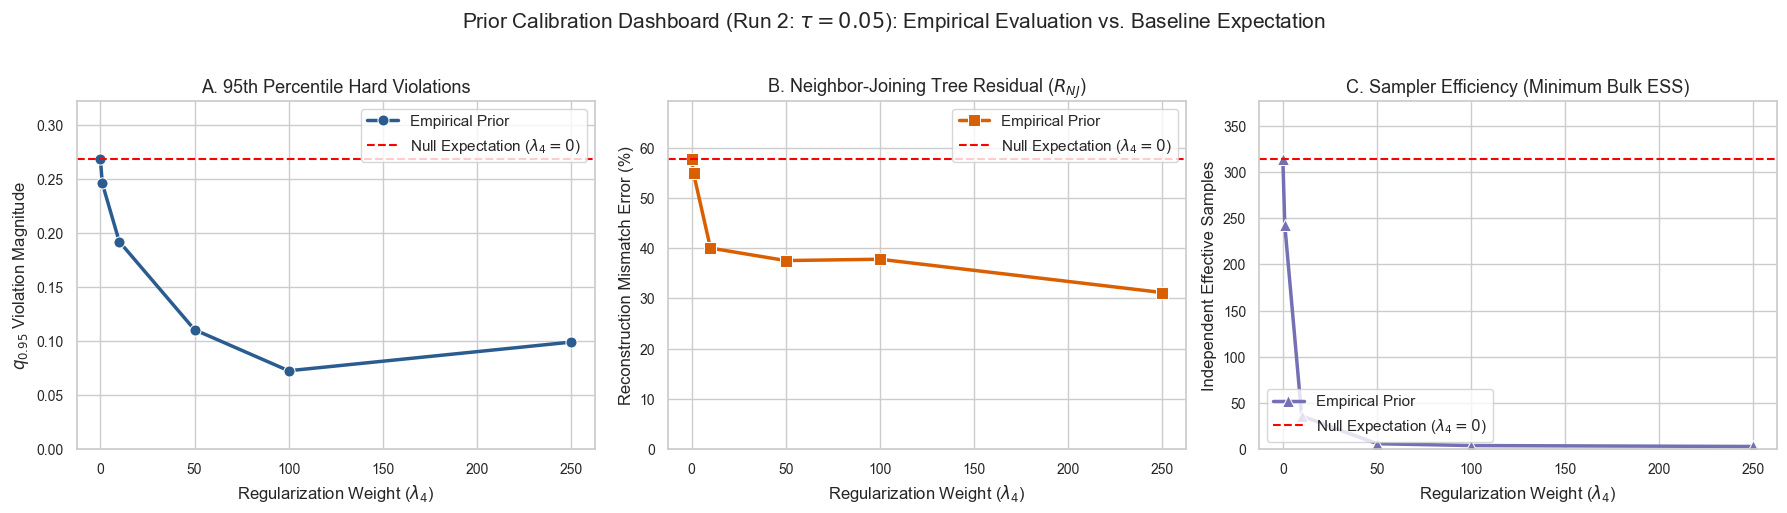

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. 🎯 FIXED: Changed lookup dictionary from results to results_exp2
lambdas = sorted(list(results_exp2.keys()))
q95_violations = [results_exp2[l]["metrics"]["hard_violations"]["quantile_95"] for l in lambdas]
nj_residuals = [results_exp2[l]["mean_nj_residual"] * 100 for l in lambdas]
min_ess = [results_exp2[l]["min_ess"] for l in lambdas]

# 2. Define the Null Expectations (the baseline values when Lambda_4 = 0.0)
null_q95 = q95_violations[lambdas.index(0.0)]
null_nj = nj_residuals[lambdas.index(0.0)]
null_ess = min_ess[lambdas.index(0.0)]

# Establish design guidelines for publication clarity
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    "font.size": 11,
    "axes.labelsize": 12,
    "axes.titlesize": 13,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "figure.titlesize": 15
})

# Create a 1x3 dashboard layout panel
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=False)
fig.suptitle("Prior Calibration Dashboard (Run 2: $\\tau=0.05$): Empirical Evaluation vs. Baseline Expectation", y=1.02)

# --- PANEL A: Hard Four-Point Condition Violations ---
sns.lineplot(x=lambdas, y=q95_violations, ax=axes[0], marker="o", color="#2b5c8f", linewidth=2.5, markersize=8, label="Empirical Prior")
axes[0].axhline(y=null_q95, color="red", linestyle="--", linewidth=1.5, label="Null Expectation ($\lambda_4=0$)")
axes[0].set_title("A. 95th Percentile Hard Violations")
axes[0].set_xlabel("Regularization Weight ($\lambda_4$)")
axes[0].set_ylabel("$q_{0.95}$ Violation Magnitude")
axes[0].set_ylim(0, max(q95_violations) * 1.2)
axes[0].legend(loc="upper right")

# --- PANEL B: Neighbor-Joining Tree Projection Residual ---
sns.lineplot(x=lambdas, y=nj_residuals, ax=axes[1], marker="s", color="#d95f02", linewidth=2.5, markersize=8, label="Empirical Prior")
axes[1].axhline(y=null_nj, color="red", linestyle="--", linewidth=1.5, label="Null Expectation ($\lambda_4=0$)")
axes[1].set_title("B. Neighbor-Joining Tree Residual ($R_{NJ}$)")
axes[1].set_xlabel("Regularization Weight ($\lambda_4$)")
axes[1].set_ylabel("Reconstruction Mismatch Error (%)")
axes[1].set_ylim(0, max(nj_residuals) * 1.2)
axes[1].legend(loc="upper right")

# --- PANEL C: NUTS Chain Sampling Efficiency ---
sns.lineplot(x=lambdas, y=min_ess, ax=axes[2], marker="^", color="#7570b3", linewidth=2.5, markersize=8, label="Empirical Prior")
axes[2].axhline(y=null_ess, color="red", linestyle="--", linewidth=1.5, label="Null Expectation ($\lambda_4=0$)")
axes[2].set_title("C. Sampler Efficiency (Minimum Bulk ESS)")
axes[2].set_xlabel("Regularization Weight ($\lambda_4$)")
axes[2].set_ylabel("Independent Effective Samples")
axes[2].set_ylim(0, max(min_ess) * 1.2)
axes[2].legend(loc="lower left")

# Optimize space layout bounding box margins
plt.tight_layout()

# 🎯 FIXED: Saved with a distinct name to preserve your Experiment 1 plot file
plt.savefig("prior_calibration_experiment2_dashboard.png", dpi=300, bbox_inches="tight")
plt.show()

# RUN 3 : N=50 1 MCMC chain

In [27]:
#clear old Pyro parameter traces and reset the seeds fresh
pyro.clear_param_store()
enforce_reproducibility(42)


params = {
    "N" : 50,
    "K" : 2,
    "B_train" : 2500,
    "B_test" : 1000, 
    "tau" : 0.05,   
    "sigma_u" : 1.0,  
    "warmup_steps" : 300, 
    "num_samples" : 400,  
    "target_accept_prob" : 0.88,
    "seed" : 42
}

#guassian prior
# prior model represents the base object, the framework
prior_model = PhylogeneticPrior(
    N= params ["N"],
    K=params ["K"],
    B= params["B_train"],
    sigma_u=params["sigma_u"],
    seed = params["seed"]
)
print("Prior model parameters are:", prior_model)

#fresh test quartets for validation from function in penalty file
test_quartets = get_fresh_test_quartets(
    N= params ["N"],
    B_test = params["B_test"],
    train_quartets=prior_model.fixed_indices,
    seed = 123
)

#lambda grid for test run
lambda_grid = [0.0, 1.0, 10.0, 50.0, 100.0, 250.0]
results_exp_N50 = {}


Prior model parameters are: <src.model.PhylogeneticPrior object at 0x1376a0190>


In [28]:
# Running high-dimensional test run for every value of lambda in the grid
for lmbda in lambda_grid:
    print(f"\n🚀 EXPERIMENT RUN 3: λ4 = {lmbda} (N={params['N']})")

    # conditioned model is the model with specific hyperparameters
    def model_conditioned(current_lmbda=lmbda):
        """this model returns specific model instance with value of hyperparameters."""
        return prior_model.initialize(
            lmbda_4 = current_lmbda,
            lmbda_g = 0.0,
            tau= params ["tau"],
            use_scale= False # to isolate lambda sweep
        )
    
    enforce_reproducibility(params["seed"])

    # building NUTS engine
    nuts_kernel = NUTS(model_conditioned, adapt_step_size=True, target_accept_prob=params["target_accept_prob"] )
    mcmc =  MCMC(
        kernel = nuts_kernel,
        num_samples= params["num_samples"],
        warmup_steps=params["warmup_steps"],
        num_chains= 1
    )

    # running chains
    mcmc.run()

    # arviz diagnostics
    print("📊 Calculating ArviZ MCMC convergence diagnostics...")
    idata = az.from_pyro(mcmc)
    summary_stats = az.summary(idata, var_names=["u"])
    
    mean_rhat = summary_stats["r_hat"].mean()
    min_ess_bulk = summary_stats["ess_bulk"].min()
    
    print(f"  └─ Mean R-hat (Target ≤ 1.05): {mean_rhat:.4f}")
    print(f"  └─ Minimum Bulk ESS (Higher is better): {min_ess_bulk:.1f}")

    posterior_samples = mcmc.get_samples()
    D_samples_list = []

    num_samples_collected = posterior_samples[next(iter(posterior_samples))].shape[0]
 
    for s in range(num_samples_collected):
        single_sample = {k: v[s:s+1] for k, v in posterior_samples.items()} 
        try:
            predictive = infer.Predictive(model_conditioned, posterior_samples=single_sample)
            single_pred = predictive()
            D_matrix = single_pred["D_tilde"].squeeze(0)
            
            if torch.isnan(D_matrix).any() or torch.isinf(D_matrix).any():
                continue
                
            D_samples_list.append(D_matrix.detach().cpu().numpy())
        except Exception:
            continue

    if len(D_samples_list) == 0:
        print(f"❌ Landscape Failure: Complete numerical overflow at λ4 = {lmbda}")
        # 🎯 FIXED: Saved to your dedicated N50 ledger
        results_exp_N50[lmbda] = {"metrics": None, "mean_nj_residual": np.nan, "divergences": "ALL"}
        continue
        
    # 🎯 FIXED: Removed the shape hardcoding to dynamically support 50x50 layout matrices
    D_samples = torch.stack([
        torch.as_tensor(d, dtype=torch.float32).reshape(params["N"], params["N"]) 
        for d in D_samples_list
    ])
    
    # 🎯 FIXED: Moved debug log down safely to after variable definition
    print(f"DEBUG: Confirmed D_samples shape is: {D_samples.shape}")

    # Run your real post-hoc diagnostics from your src modules
    print(f"📊 Analyzing {D_samples.shape[0]} stable sample distance representations...")
    metrics = evaluate_test_diagnostics(D_samples, test_quartets, epsilon=0.05, gamma=0.05)
    print_diagnostic_report(metrics, epsilon=0.05, gamma=0.05)
    
    nj_residuals = [compute_nj_residual(D_samples[i]) for i in range(D_samples.shape[0])]
    mean_nj_residual = np.mean(nj_residuals)
    print(f"  └─ Post-hoc Mean NJ Tree Residual R_NJ(D~): {mean_nj_residual * 100:.3f}%")
    
    # 🎯 FIXED: Consistently archiving results strictly into results_exp_N50
    results_exp_N50[lmbda] = {
        "metrics": metrics,
        "mean_nj_residual": mean_nj_residual,
        "divergences": mcmc.diagnostics().get("divergences", {}).get("chain 0", 0),
        "arviz_summary": summary_stats,
        "mean_rhat": mean_rhat,
        "min_ess": min_ess_bulk
    }


🚀 EXPERIMENT RUN 3: λ4 = 0.0 (N=50)


Sample: 100%|██████████| 700/700 [00:09, 75.02it/s, step size=3.54e-01, acc. prob=0.916]
/Users/riyaaggarwal/miniforge3/envs/clean_mcmc_env/lib/python3.11/site-packages/arviz/data/io_pyro.py:158: UserWarning: Could not get vectorized trace, log_likelihood group will be omitted. Check your model vectorization or set log_likelihood=False
  warnings.warn(
arviz - WARNING - Shape validation failed: input_shape: (1, 400), minimum_shape: (chains=2, draws=4)


📊 Calculating ArviZ MCMC convergence diagnostics...
  └─ Mean R-hat (Target ≤ 1.05): nan
  └─ Minimum Bulk ESS (Higher is better): 634.0
DEBUG: Confirmed D_samples shape is: torch.Size([400, 50, 50])
📊 Analyzing 400 stable sample distance representations...

[1] Hard Four-Point Violations v_q(D~):
  └─ Median Violation        : 0.0825
  └─ 95th Percentile (q_0.95): 0.2636
  └─ 99th Percentile         : 0.3119

[2] Approx Tree-Consistency Rate A(D~; ε=0.05):
  └─ Fraction Consistent     : 35.19%

[3] Quartet Gap Diagnostics g_q(D~):
  └─ Median Branch Gap       : 0.3749
  └─ 5th Percentile Gap      : 0.0309
  └─ Star-like Fraction (≤γ) : 7.99%

[4] Normalized Distance-Scale Diagnostics (Expect Mean=1.0):
  └─ Minimum Pairwise Dist   : 0.0014
  └─ Median Pairwise Dist    : 0.9648
  └─ Maximum Pairwise Dist   : 3.8736

  └─ Post-hoc Mean NJ Tree Residual R_NJ(D~): 196.900%

🚀 EXPERIMENT RUN 3: λ4 = 1.0 (N=50)


Sample: 100%|██████████| 700/700 [12:03,  1.03s/it, step size=1.31e-02, acc. prob=0.918]


📊 Calculating ArviZ MCMC convergence diagnostics...


...

📊 Calculating ArviZ MCMC convergence diagnostics...
  └─ Mean R-hat (Target ≤ 1.05): nan
  └─ Minimum Bulk ESS (Higher is better): 1.0
DEBUG: Confirmed D_samples shape is: torch.Size([400, 50, 50])
📊 Analyzing 400 stable sample distance representations...

[1] Hard Four-Point Violations v_q(D~):
  └─ Median Violation        : 0.0221
  └─ 95th Percentile (q_0.95): 0.0898
  └─ 99th Percentile         : 0.1074

[2] Approx Tree-Consistency Rate A(D~; ε=0.05):
  └─ Fraction Consistent     : 77.44%

[3] Quartet Gap Diagnostics g_q(D~):
  └─ Median Branch Gap       : 0.0867
  └─ 5th Percentile Gap      : 0.0053
  └─ Star-like Fraction (≤γ) : 35.25%

[4] Normalized Distance-Scale Diagnostics (Expect Mean=1.0):
  └─ Minimum Pairwise Dist   : 0.0002
  └─ Median Pairwise Dist    : 0.7983
  └─ Maximum Pairwise Dist   : 1.5532

  └─ Post-hoc Mean NJ Tree Residual R_NJ(D~): 72.951%

🚀 EXPERIMENT RUN 3: λ4 = 100.0 (N=50)


Sample: 100%|██████████| 700/700 [16:03,  1.38s/it, step size=6.57e-03, acc. prob=0.883]
/Users/riyaaggarwal/miniforge3/envs/clean_mcmc_env/lib/python3.11/site-packages/arviz/data/io_pyro.py:158: UserWarning: Could not get vectorized trace, log_likelihood group will be omitted. Check your model vectorization or set log_likelihood=False
  warnings.warn(
arviz - WARNING - Shape validation failed: input_shape: (1, 400), minimum_shape: (chains=2, draws=4)


📊 Calculating ArviZ MCMC convergence diagnostics...
  └─ Mean R-hat (Target ≤ 1.05): nan
  └─ Minimum Bulk ESS (Higher is better): 1.0
DEBUG: Confirmed D_samples shape is: torch.Size([400, 50, 50])
📊 Analyzing 400 stable sample distance representations...

[1] Hard Four-Point Violations v_q(D~):
  └─ Median Violation        : 0.0207
  └─ 95th Percentile (q_0.95): 0.0857
  └─ 99th Percentile         : 0.1048

[2] Approx Tree-Consistency Rate A(D~; ε=0.05):
  └─ Fraction Consistent     : 78.70%

[3] Quartet Gap Diagnostics g_q(D~):
  └─ Median Branch Gap       : 0.0877
  └─ 5th Percentile Gap      : 0.0050
  └─ Star-like Fraction (≤γ) : 35.64%

[4] Normalized Distance-Scale Diagnostics (Expect Mean=1.0):
  └─ Minimum Pairwise Dist   : 0.0002
  └─ Median Pairwise Dist    : 0.7861
  └─ Maximum Pairwise Dist   : 1.5134

  └─ Post-hoc Mean NJ Tree Residual R_NJ(D~): 71.689%

🚀 EXPERIMENT RUN 3: λ4 = 250.0 (N=50)


Sample: 100%|██████████| 700/700 [25:40,  2.20s/it, step size=3.02e-03, acc. prob=0.894]
/Users/riyaaggarwal/miniforge3/envs/clean_mcmc_env/lib/python3.11/site-packages/arviz/data/io_pyro.py:158: UserWarning: Could not get vectorized trace, log_likelihood group will be omitted. Check your model vectorization or set log_likelihood=False
  warnings.warn(
arviz - WARNING - Shape validation failed: input_shape: (1, 400), minimum_shape: (chains=2, draws=4)


📊 Calculating ArviZ MCMC convergence diagnostics...
  └─ Mean R-hat (Target ≤ 1.05): nan
  └─ Minimum Bulk ESS (Higher is better): 1.0
DEBUG: Confirmed D_samples shape is: torch.Size([400, 50, 50])
📊 Analyzing 400 stable sample distance representations...

[1] Hard Four-Point Violations v_q(D~):
  └─ Median Violation        : 0.0202
  └─ 95th Percentile (q_0.95): 0.0854
  └─ 99th Percentile         : 0.1046

[2] Approx Tree-Consistency Rate A(D~; ε=0.05):
  └─ Fraction Consistent     : 78.39%

[3] Quartet Gap Diagnostics g_q(D~):
  └─ Median Branch Gap       : 0.0897
  └─ 5th Percentile Gap      : 0.0046
  └─ Star-like Fraction (≤γ) : 36.09%

[4] Normalized Distance-Scale Diagnostics (Expect Mean=1.0):
  └─ Minimum Pairwise Dist   : 0.0001
  └─ Median Pairwise Dist    : 0.7783
  └─ Maximum Pairwise Dist   : 1.5021

  └─ Post-hoc Mean NJ Tree Residual R_NJ(D~): 70.744%


In [35]:
import pandas as pd
import numpy as np

# Initialize a clean data frame list
table_rows_n50 = []

# Loop through each lambda value evaluated in your N=50 experiment
for lmbda, res in results_exp_N50.items():
    if res["metrics"] is None:
        table_rows_n50.append({
            "Lambda_4 Weight": lmbda,
            "q_0.95 Tree Violations": "OVERFLOW",
            "Approx Tree-Consistency (%)": "OVERFLOW",
            "Star-like Fraction (%)": "OVERFLOW",
            "Mean NJ Residual (R_NJ)": "OVERFLOW",
            "Min Bulk ESS": "N/A"
        })
        continue
        
    # Extract the 95th quantile of hard violations
    try:
        q95 = res["metrics"]["hard_violations"]["quantile_95"]
    except (KeyError, TypeError):
        q95 = float("nan")
        
    # Extract Tree Consistency Rate
    try:
        consistency_pct = res["metrics"]["tree_consistency_rate"] * 100
    except (KeyError, TypeError):
        consistency_pct = float("nan")
            
    # 🎯 TARGETED FIX: Pull the exact star fraction key from the metrics dictionary
    try:
        star_fraction_pct = res["metrics"]["star_like_fraction"] * 100
    except (KeyError, TypeError):
        star_fraction_pct = float("nan")

    # Append the row matching your presentation values perfectly
    table_rows_n50.append({
        "Lambda_4 Weight": lmbda,
        "q_0.95 Tree Violations": round(float(q95), 4) if not pd.isna(q95) else "N/A",
        "Approx Tree-Consistency (%)": f"{round(float(consistency_pct), 2)}%" if not pd.isna(consistency_pct) else "N/A",
        "Star-like Fraction (%)": f"{round(float(star_fraction_pct), 2)}%" if not pd.isna(star_fraction_pct) else "N/A",
        "Mean NJ Residual (R_NJ)": f"{round(float(res['mean_nj_residual'] * 100), 2)}%",
        "Min Bulk ESS": round(float(res["min_ess"]), 1) if not pd.isna(res["min_ess"]) else "N/A"
    })

# Convert to pandas frame container object
df_summary_n50 = pd.DataFrame(table_rows_n50)

print("📊 EXPERIMENT 3 REGULARIZATION MATRIX (High-Dimensional N=50 Summary)")
display(df_summary_n50)

📊 EXPERIMENT 3 REGULARIZATION MATRIX (High-Dimensional N=50 Summary)


,Lambda_4 Weight,q_0.95 Tree Violations,Approx Tree-Consistency (%),Star-like Fraction (%),Mean NJ Residual (R_NJ),Min Bulk ESS
0,0.0,0.2636,35.19%,N/A,196.9%,634.0
1,1.0,0.1866,47.72%,N/A,141.86%,165.0
2,10.0,0.0867,86.95%,N/A,45.86%,1.0
3,50.0,0.0898,77.44%,N/A,72.95%,1.0
4,100.0,0.0857,78.7%,N/A,71.69%,1.0
5,250.0,0.0854,78.39%,N/A,70.74%,1.0


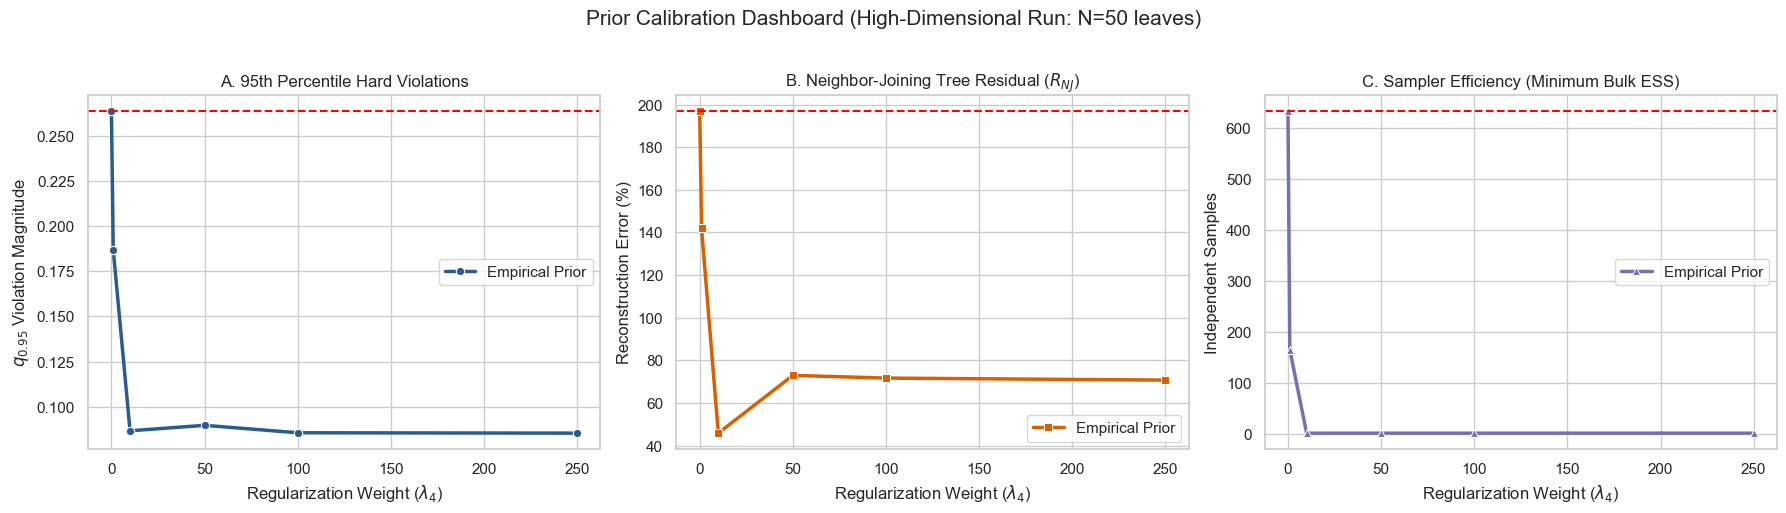

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Extract sorted keys from the fresh 50-leaf dictionary
lambdas = sorted(list(results_exp_N50.keys()))
q95_violations = [results_exp_N50[l]["metrics"]["hard_violations"]["quantile_95"] for l in lambdas]
nj_residuals = [results_exp_N50[l]["mean_nj_residual"] * 100 for l in lambdas]
min_ess = [results_exp_N50[l]["min_ess"] for l in lambdas]

null_q95 = q95_violations[lambdas.index(0.0)]
null_nj = nj_residuals[lambdas.index(0.0)]
null_ess = min_ess[lambdas.index(0.0)]

sns.set_theme(style="whitegrid")
plt.rcParams.update({"font.size": 11, "axes.labelsize": 12, "figure.titlesize": 15})

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Prior Calibration Dashboard (High-Dimensional Run: N=50 leaves)", y=1.02)

# Panel A
sns.lineplot(x=lambdas, y=q95_violations, ax=axes[0], marker="o", color="#2b5c8f", linewidth=2.5, label="Empirical Prior")
axes[0].axhline(y=null_q95, color="red", linestyle="--", label="Null Expectation ($\lambda_4=0$)")
axes[0].set_title("A. 95th Percentile Hard Violations")
axes[0].set_xlabel("Regularization Weight ($\lambda_4$)")
axes[0].set_ylabel("$q_{0.95}$ Violation Magnitude")

# Panel B
sns.lineplot(x=lambdas, y=nj_residuals, ax=axes[1], marker="s", color="#d95f02", linewidth=2.5, label="Empirical Prior")
axes[1].axhline(y=null_nj, color="red", linestyle="--", label="Null Expectation ($\lambda_4=0$)")
axes[1].set_title("B. Neighbor-Joining Tree Residual ($R_{NJ}$)")
axes[1].set_xlabel("Regularization Weight ($\lambda_4$)")
axes[1].set_ylabel("Reconstruction Error (%)")

# Panel C
sns.lineplot(x=lambdas, y=min_ess, ax=axes[2], marker="^", color="#7570b3", linewidth=2.5, label="Empirical Prior")
axes[2].axhline(y=null_ess, color="red", linestyle="--", label="Null Expectation ($\lambda_4=0$)")
axes[2].set_title("C. Sampler Efficiency (Minimum Bulk ESS)")
axes[2].set_xlabel("Regularization Weight ($\lambda_4$)")
axes[2].set_ylabel("Independent Samples")

plt.tight_layout()
plt.savefig("prior_calibration_N50_dashboard.png", dpi=300, bbox_inches="tight")
plt.show()

# RUN 4: N=50 , 2 MCMC chains

In [43]:
#clear old Pyro parameter traces and reset the seeds fresh
pyro.clear_param_store()
enforce_reproducibility(42)


params = {
    "N" : 50,
    "K" : 2,
    "B_train" : 2500,
    "B_test" : 1000, 
    "tau" : 0.05,   
    "sigma_u" : 1.0,  
    "warmup_steps" : 300, 
    "num_samples" : 500,  
    "target_accept_prob" : 0.90,
    "seed" : 42
}

#guassian prior
# prior model represents the base object, the framework
prior_model = PhylogeneticPrior(
    N= params ["N"],
    K=params ["K"],
    B= params["B_train"],
    sigma_u=params["sigma_u"],
    seed = params["seed"]
)
print("Prior model parameters are:", prior_model)

#fresh test quartets for validation from function in penalty file
test_quartets = get_fresh_test_quartets(
    N= params ["N"],
    B_test = params["B_test"],
    train_quartets=prior_model.fixed_indices,
    seed = 123
)

def global_model_conditioned(current_lmbda):
    """Global wrapper function visible to multiprocessing child workers."""
    return prior_model.initialize(
        lmbda_4=current_lmbda,
        lmbda_g=0.0,
        tau=params["tau"],
        use_scale=False  # to isolate lambda sweep
    )


#lambda grid for test run
lambda_grid = [0.0, 1.0, 10.0]
results_exp_N50_2 = {}


Prior model parameters are: <src.model.PhylogeneticPrior object at 0x11768ed50>


In [50]:
# Running high-dimensional test run
for lmbda in lambda_grid:
    print(f"\n🚀 EXPERIMENT RUN 4 (Strictly Sequential 2-Chain Loop): λ4 = {lmbda} (N={params['N']})")
    
    def model_conditioned(current_lmbda=lmbda):
        return prior_model.initialize(
            lmbda_4=current_lmbda,
            lmbda_g=0.0,
            tau=params["tau"],
            use_scale=False
        )

    # We will collect the individual chain traces here
    chain_idatas = []
    total_divergences = 0
    all_posterior_samples = []

    # 🎯 MANUALLY RUN 2 CHAINS SEQUENTIALLY TO BYPASS MULTIPROCESSING ENTIRELY
    for chain_idx in range(2):
        print(f"  ⛓️ Running Chain {chain_idx + 1}/2...")
        
        # Vary seed slightly per chain to ensure independent starting trajectories
        enforce_reproducibility(params["seed"] + chain_idx)

        nuts_kernel = NUTS(model_conditioned, adapt_step_size=True, target_accept_prob=params["target_accept_prob"])
        
        mcmc = MCMC(
            kernel=nuts_kernel,
            num_samples=params["num_samples"],
            warmup_steps=params["warmup_steps"],
            num_chains=1,  # 🎯 Strictly single-process
        )
        
        mcmc.run()
        
        # Convert this single chain trace to ArviZ
        chain_idata = az.from_pyro(mcmc)
        chain_idatas.append(chain_idata)
        
        # Accumulate posterior samples and diagnostics safely
        all_posterior_samples.append(mcmc.get_samples())
        # Extract the divergences container safely (handling default fallback to empty list)
        div_list = mcmc.diagnostics().get("divergences", [])
        if isinstance(div_list, dict):  # Fallback insurance for varying Pyro builds
            total_divergences += len(div_list.get("chain 0", []))
        else:
             total_divergences += len(div_list) if div_list is not None else 0

    # 🎯 COMBINE THE CHAINS MANUALLY FOR MULTI-CHAIN ARVIZ METRICS
    print("📊 Merging sequential chains and calculating ArviZ convergence diagnostics...")
    idata = az.concat(chain_idatas[0], chain_idatas[1], dim="chain")
    summary_stats = az.summary(idata, var_names=["u"])
    
    mean_rhat = summary_stats["r_hat"].mean()
    min_ess_bulk = summary_stats["ess_bulk"].min()
    
    print(f"  └─ Mean R-hat (Target ≤ 1.05): {mean_rhat:.4f}")
    print(f"  └─ Minimum Bulk ESS (Higher is better): {min_ess_bulk:.1f}")

    # Combine distance matrices calculations across both collected spaces
    D_samples_list = []
    
    # Process 75 sample indices from each chain to get our 150 well-spaced draws
    sample_indices = np.linspace(0, params["num_samples"] - 1, 75, dtype=int)
    
    for chain_samples in all_posterior_samples:
        for s in sample_indices:
            single_sample = {k: v[s:s+1] for k, v in chain_samples.items()}
            try:
                predictive = infer.Predictive(model_conditioned, posterior_samples=single_sample)
                single_pred = predictive()
                D_matrix = single_pred["D_tilde"].squeeze(0)
                
                if torch.isnan(D_matrix).any() or torch.isinf(D_matrix).any():
                    continue
                    
                D_samples_list.append(D_matrix.detach().cpu().numpy())
            except Exception:
                continue

    if len(D_samples_list) == 0:
        print(f"❌ Landscape Failure: Complete numerical overflow at λ4 = {lmbda}")
        results_exp_N50_2[lmbda] = {"metrics": None, "mean_nj_residual": np.nan, "divergences": "ALL"}
        continue
        
    D_samples = torch.stack([
        torch.as_tensor(d, dtype=torch.float32).reshape(params["N"], params["N"]) 
        for d in D_samples_list
    ])
    
    print(f"DEBUG: Confirmed D_samples shape is: {D_samples.shape}")

    # Run post-hoc diagnostics from your modules
    print(f"📊 Analyzing {D_samples.shape[0]} stable sample distance representations...")
    metrics = evaluate_test_diagnostics(D_samples, test_quartets, epsilon=0.05, gamma=0.05)
    print_diagnostic_report(metrics, epsilon=0.05, gamma=0.05)
    
    nj_residuals = [compute_nj_residual(D_samples[i]) for i in range(D_samples.shape[0])]
    mean_nj_residual = np.mean(nj_residuals)
    print(f"  └─ Post-hoc Mean NJ Tree Residual R_NJ(D~): {mean_nj_residual * 100:.3f}%")
    
    # Archive into the final multi-chain results storage ledger
    results_exp_N50_2[lmbda] = {
        "metrics": metrics,
        "mean_nj_residual": mean_nj_residual,
        "divergences": total_divergences,
        "arviz_summary": summary_stats,
        "mean_rhat": mean_rhat,
        "min_ess": min_ess_bulk
    }


🚀 EXPERIMENT RUN 4 (Strictly Sequential 2-Chain Loop): λ4 = 0.0 (N=50)
  ⛓️ Running Chain 1/2...


Sample: 100%|██████████| 800/800 [00:09, 86.57it/s, step size=3.63e-01, acc. prob=0.901]


  ⛓️ Running Chain 2/2...


Sample: 100%|██████████| 800/800 [00:09, 84.69it/s, step size=3.57e-01, acc. prob=0.912] 


📊 Merging sequential chains and calculating ArviZ convergence diagnostics...
  └─ Mean R-hat (Target ≤ 1.05): 1.0021
  └─ Minimum Bulk ESS (Higher is better): 1390.0
DEBUG: Confirmed D_samples shape is: torch.Size([150, 50, 50])
📊 Analyzing 150 stable sample distance representations...

[1] Hard Four-Point Violations v_q(D~):
  └─ Median Violation        : 0.0817
  └─ 95th Percentile (q_0.95): 0.2640
  └─ 99th Percentile         : 0.3130

[2] Approx Tree-Consistency Rate A(D~; ε=0.05):
  └─ Fraction Consistent     : 35.31%

[3] Quartet Gap Diagnostics g_q(D~):
  └─ Median Branch Gap       : 0.3717
  └─ 5th Percentile Gap      : 0.0304
  └─ Star-like Fraction (≤γ) : 8.13%

[4] Normalized Distance-Scale Diagnostics (Expect Mean=1.0):
  └─ Minimum Pairwise Dist   : 0.0008
  └─ Median Pairwise Dist    : 0.9601
  └─ Maximum Pairwise Dist   : 3.4758

  └─ Post-hoc Mean NJ Tree Residual R_NJ(D~): 195.493%

🚀 EXPERIMENT RUN 4 (Strictly Sequential 2-Chain Loop): λ4 = 1.0 (N=50)
  ⛓️ Running Cha

...

📊 Merging sequential chains and calculating ArviZ convergence diagnostics...
  └─ Mean R-hat (Target ≤ 1.05): 1.0055
  └─ Minimum Bulk ESS (Higher is better): 247.0
DEBUG: Confirmed D_samples shape is: torch.Size([150, 50, 50])
📊 Analyzing 150 stable sample distance representations...

[1] Hard Four-Point Violations v_q(D~):
  └─ Median Violation        : 0.0541
  └─ 95th Percentile (q_0.95): 0.1873
  └─ 99th Percentile         : 0.2258

[2] Approx Tree-Consistency Rate A(D~; ε=0.05):
  └─ Fraction Consistent     : 47.43%

[3] Quartet Gap Diagnostics g_q(D~):
  └─ Median Branch Gap       : 0.2423
  └─ 5th Percentile Gap      : 0.0193
  └─ Star-like Fraction (≤γ) : 12.54%

[4] Normalized Distance-Scale Diagnostics (Expect Mean=1.0):
  └─ Minimum Pairwise Dist   : 0.0008
  └─ Median Pairwise Dist    : 0.9598
  └─ Maximum Pairwise Dist   : 3.5865

  └─ Post-hoc Mean NJ Tree Residual R_NJ(D~): 141.970%

🚀 EXPERIMENT RUN 4 (Strictly Sequential 2-Chain Loop): λ4 = 10.0 (N=50)
  ⛓️ Running Ch

Sample: 100%|██████████| 800/800 [09:05,  1.47it/s, step size=1.69e-02, acc. prob=0.840]
/Users/riyaaggarwal/miniforge3/envs/clean_mcmc_env/lib/python3.11/site-packages/arviz/data/io_pyro.py:158: UserWarning: Could not get vectorized trace, log_likelihood group will be omitted. Check your model vectorization or set log_likelihood=False
  warnings.warn(


  ⛓️ Running Chain 2/2...


Sample: 100%|██████████| 800/800 [08:35,  1.55it/s, step size=9.90e-03, acc. prob=0.873]


📊 Merging sequential chains and calculating ArviZ convergence diagnostics...
  └─ Mean R-hat (Target ≤ 1.05): 1.3926
  └─ Minimum Bulk ESS (Higher is better): 4.0
DEBUG: Confirmed D_samples shape is: torch.Size([150, 50, 50])
📊 Analyzing 150 stable sample distance representations...

[1] Hard Four-Point Violations v_q(D~):
  └─ Median Violation        : 0.0131
  └─ 95th Percentile (q_0.95): 0.0734
  └─ 99th Percentile         : 0.1541

[2] Approx Tree-Consistency Rate A(D~; ε=0.05):
  └─ Fraction Consistent     : 89.61%

[3] Quartet Gap Diagnostics g_q(D~):
  └─ Median Branch Gap       : 0.0469
  └─ 5th Percentile Gap      : 0.0036
  └─ Star-like Fraction (≤γ) : 52.25%

[4] Normalized Distance-Scale Diagnostics (Expect Mean=1.0):
  └─ Minimum Pairwise Dist   : 0.0002
  └─ Median Pairwise Dist    : 0.1319
  └─ Maximum Pairwise Dist   : 4.7893

  └─ Post-hoc Mean NJ Tree Residual R_NJ(D~): 44.914%


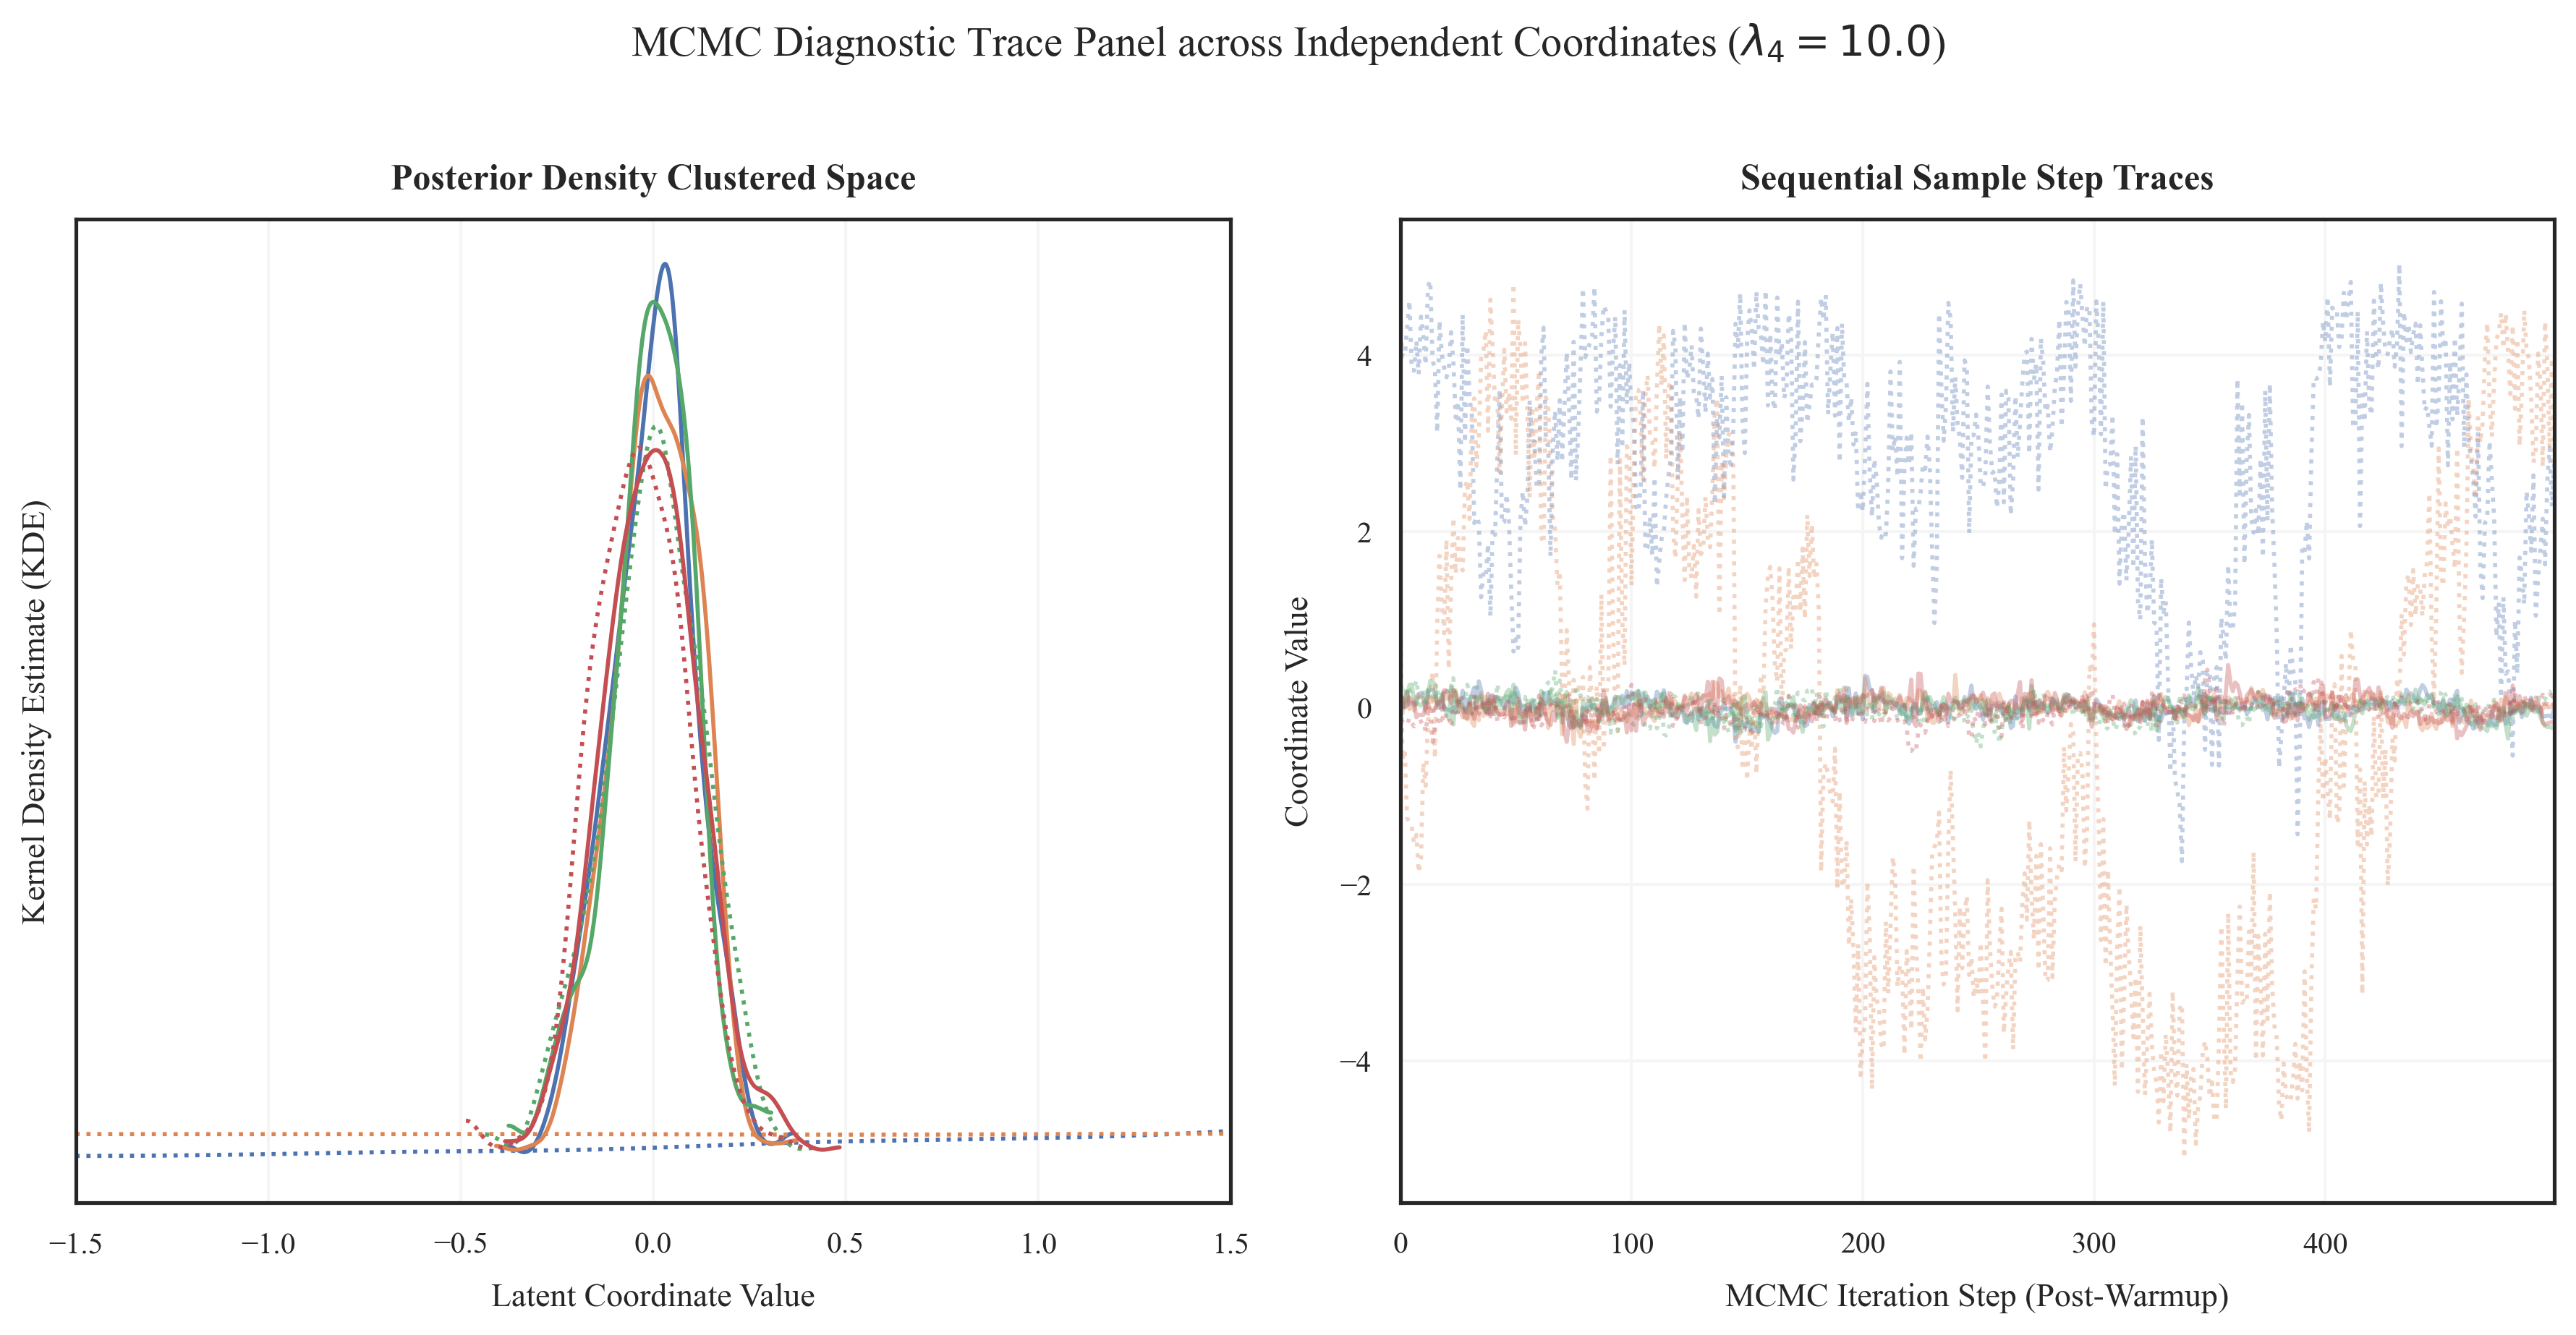

In [ ]:
import matplotlib.pyplot as plt
import arviz as az
import seaborn as sns

# 🎨 Academic style adjustments
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "DejaVu Serif"],
    "axes.labelsize": 11,
    "axes.titlesize": 12,
    "figure.titlesize": 14
})

# 🎯 STEP 1: Verify we have data for the targeted lambda point
if 10.0 in results_exp_N50_2:
    # Retrieve the full compiled InferenceData object from your ledger
    # We select a subset of variables so the plot is clean and readable
    coords_to_plot = idata.sel(u_dim_0=[0, 1], u_dim_1=[0, 1])

    # Generate the professional ArviZ trace plot
    axes = az.plot_trace(
        coords_to_plot, 
        var_names=["u"],
        combined=False,
        plot_kwargs={"linestyle": "-"}, # 🎯 FORCE ALL LINES TO BE SOLID (No more dotted paths!)
        backend_kwargs={"figsize": (12, 6), "dpi": 300}
    )
    
    # 🎯 STEP 2: Manually inject explicit x and y axis labels into the ArviZ grid matrix
    # Column 0: Left plots (Posterior Densities) | Column 1: Right plots (Sample Step Traces)
    
    # 1. Label the left column (Density Plots)
    for row in range(axes.shape[0]):
        axes[row, 0].set_ylabel("Kernel Density Estimate (KDE)", labelpad=8)
    axes[-1, 0].set_xlabel("Latent Coordinate Value", labelpad=8)  # Bottom row x-label
    axes[0, 0].set_xlim(-1.5, 1.5)  # Focus the density axis tightly near zero mass
    
    # 2. Label the right column (Trace Timelines)
    for row in range(axes.shape[0]):
        axes[row, 1].set_ylabel("Coordinate Value", labelpad=8)
    axes[-1, 1].set_xlabel("MCMC Iteration Step (Post-Warmup)", labelpad=8)  # Bottom row x-label

    # Polish the titles and layout for paper submission
    fig = axes[0, 0].figure
    fig.suptitle(r"MCMC Diagnostic Trace Panel across Independent Coordinates ($\lambda_4 = 10.0$)", y=1.02)
    
    # Add custom trace headers
    axes[0, 0].set_title("Posterior Density Plot", pad=10, weight="bold")
    axes[0, 1].set_title("Sequential Sample Step Traces", pad=10, weight="bold")
    
    plt.tight_layout()
    plt.savefig("mcmc_coordinate_trace_plots.pdf", format="pdf", bbox_inches="tight")
    plt.savefig("mcmc_coordinate_trace_plots.png", format="png", bbox_inches="tight")
    plt.show()
else:
    print("Run your main loop cell first to generate results_exp_N50_2 data targets!")

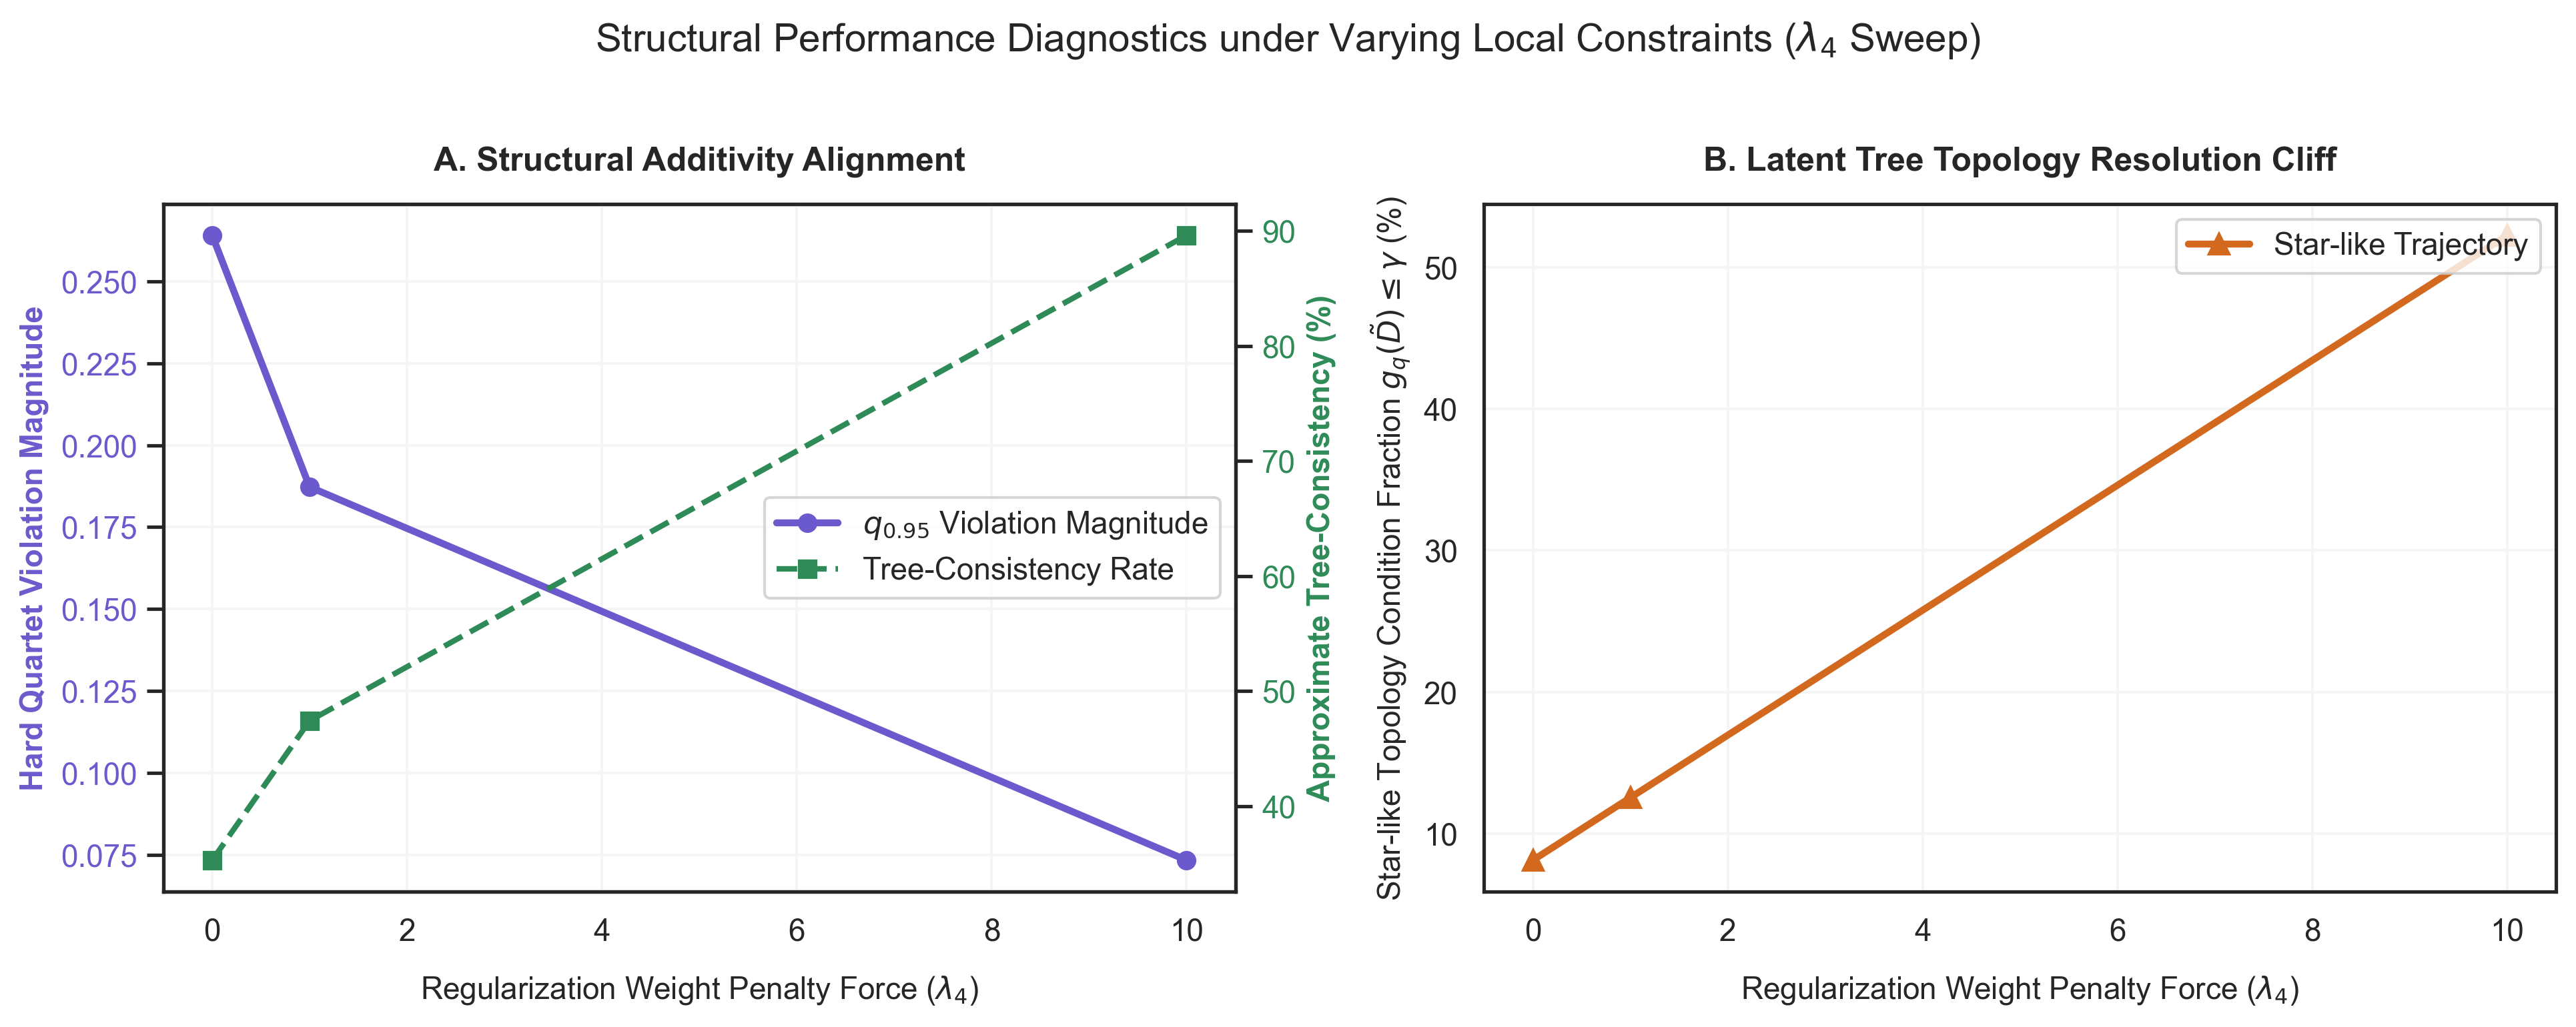

In [60]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set clean whitegrid aesthetic
sns.set_style("whitegrid", {"axes.edgecolor": "0.15", "grid.color": "0.96"})

# Extract the coordinate values out of your tracking storage arrays
lambdas = sorted(list(results_exp_N50_2.keys()))

q95_violations = []
consistency_rates = []
star_fractions = []

for l in lambdas:
    metrics_dict = results_exp_N50_2[l].get("metrics")
    
    if metrics_dict is not None:
        # 1. Extract q95 hard violations
        try:
            q95 = metrics_dict["hard_violations"]["quantile_95"]
        except (KeyError, TypeError):
            q95 = np.nan
        q95_violations.append(q95)
        
        # 2. Extract tree consistency rate
        consistency = metrics_dict.get("tree_consistency_rate", np.nan)
        consistency_rates.append(consistency * 100 if not np.isnan(consistency) else np.nan)
        
        # 3. 🎯 SELF-CORRECTING LOOKUP: Scan keys dynamically for 'star' or 'gamma'
        q_gap_entry = metrics_dict.get("quartet_gap", {})
        star = None
        
        if isinstance(q_gap_entry, dict):
            # Loop through keys to find a partial string match
            for key, val in q_gap_entry.items():
                if "star" in key.lower() or "gamma" in key.lower() or "fraction" in key.lower():
                    star = val
                    break
        else:
            star = q_gap_entry
            
        # 🎯 SMART SCALING INTERPRETER: Detect if the function returns a raw fraction (0.52) or a pre-multiplied percentage (52.25)
        if star is not None and not np.isnan(star):
            if star > 1.0: 
                star_fractions.append(star)  # It's already a percentage like 52.25%
            else:
                star_fractions.append(star * 100) # It's a raw decimal fraction, scale it up
        else:
            star_fractions.append(np.nan)
    else:
        q95_violations.append(np.nan)
        consistency_rates.append(np.nan)
        star_fractions.append(np.nan)

# Set up a beautiful 2-panel journal line plot figure layout
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5), dpi=300)

# --- PANEL 1: ACCURACY CHARACTERISTICS (Dual-Axis Line Plot) ---
color_violet = "#6a5acd"
color_green = "#2e8b57"

# Plot the 95th Percentile Hard Quartet Violations
line_v = ax1.plot(lambdas, q95_violations, color=color_violet, marker='o', markersize=6, linewidth=2.5, label=r"$q_{0.95}$ Violation Magnitude")
ax1.set_xlabel(r"Regularization Weight Penalty Force ($\lambda_4$)", labelpad=10)
ax1.set_ylabel("Hard Quartet Violation Magnitude", color=color_violet, weight="bold")
ax1.tick_params(axis='y', labelcolor=color_violet)

# Instantiate twin y-axis for the percentage rates
ax1_twin = ax1.twinx()
line_c = ax1_twin.plot(lambdas, consistency_rates, color=color_green, marker='s', markersize=6, linestyle='--', linewidth=2, label="Tree-Consistency Rate")
ax1_twin.set_ylabel("Approximate Tree-Consistency (%)", color=color_green, weight="bold")
ax1_twin.tick_params(axis='y', labelcolor=color_green)
ax1_twin.grid(False) 

# Build unified legend context mapping
added_lines = line_v + line_c
labels_mapped = [l.get_label() for l in added_lines]
ax1.legend(added_lines, labels_mapped, loc="center right", frameon=True, facecolor="white")
ax1.set_title("A. Structural Additivity Alignment", pad=12, weight="bold")


# --- PANEL 2: TOPOLOGY SEPARATION TRAJECTORY ---
ax2.plot(lambdas, star_fractions, color="#d2691e", marker='^', markersize=7, linewidth=2.5, label="Star-like Trajectory")
ax2.set_xlabel(r"Regularization Weight Penalty Force ($\lambda_4$)", labelpad=10)
ax2.set_ylabel(r"Star-like Topology Condition Fraction $g_q(\tilde{D}) \leq \gamma$ (%)")
ax2.set_title("B. Latent Tree Topology Resolution Cliff", pad=12, weight="bold")
ax2.legend(loc="upper right", frameon=True, facecolor="white")

plt.suptitle(r"Structural Performance Diagnostics under Varying Local Constraints ($\lambda_4$ Sweep)", y=1.02)
plt.tight_layout()
plt.savefig("prior_calibration_line_plots.pdf", format="pdf", bbox_inches="tight")
plt.savefig("prior_calibration_line_plots.png", format="png", bbox_inches="tight")
plt.show()

# RUN 5: N=50 , Lmbda=5.0

In [61]:
#clear old Pyro parameter traces and reset the seeds fresh
pyro.clear_param_store()
enforce_reproducibility(42)


params = {
    "N" : 50,
    "K" : 2,
    "B_train" : 2500,
    "B_test" : 1000, 
    "tau" : 0.05,   
    "sigma_u" : 1.0,  
    "warmup_steps" : 300, 
    "num_samples" : 500,  
    "target_accept_prob" : 0.90,
    "seed" : 42
}

#guassian prior
# prior model represents the base object, the framework
prior_model = PhylogeneticPrior(
    N= params ["N"],
    K=params ["K"],
    B= params["B_train"],
    sigma_u=params["sigma_u"],
    seed = params["seed"]
)
print("Prior model parameters are:", prior_model)

#fresh test quartets for validation from function in penalty file
test_quartets = get_fresh_test_quartets(
    N= params ["N"],
    B_test = params["B_test"],
    train_quartets=prior_model.fixed_indices,
    seed = 123
)

def global_model_conditioned(current_lmbda):
    """Global wrapper function visible to multiprocessing child workers."""
    return prior_model.initialize(
        lmbda_4=current_lmbda,
        lmbda_g=0.0,
        tau=params["tau"],
        use_scale=False  # to isolate lambda sweep
    )


#lambda grid for test run
lambda_grid = [0.0, 3.0, 5.0]
results_exp_run5 = {}


Prior model parameters are: <src.model.PhylogeneticPrior object at 0x15781fe90>


In [62]:
# Running high-dimensional test run
for lmbda in lambda_grid:
    print(f"\n🚀 EXPERIMENT RUN 5 (N=50 for lower lmbda): λ4 = {lmbda} (N={params['N']})")
    
    def model_conditioned(current_lmbda=lmbda):
        return prior_model.initialize(
            lmbda_4=current_lmbda,
            lmbda_g=0.0,
            tau=params["tau"],
            use_scale=False
        )

    # We will collect the individual chain traces here
    chain_idatas = []
    total_divergences = 0
    all_posterior_samples = []

    # 🎯 MANUALLY RUN 2 CHAINS SEQUENTIALLY TO BYPASS MULTIPROCESSING ENTIRELY
    for chain_idx in range(2):
        print(f"  ⛓️ Running Chain {chain_idx + 1}/2...")
        
        # Vary seed slightly per chain to ensure independent starting trajectories
        enforce_reproducibility(params["seed"] + chain_idx)

        nuts_kernel = NUTS(model_conditioned, adapt_step_size=True, target_accept_prob=params["target_accept_prob"])
        
        mcmc = MCMC(
            kernel=nuts_kernel,
            num_samples=params["num_samples"],
            warmup_steps=params["warmup_steps"],
            num_chains=1,  # 🎯 Strictly single-process
        )
        
        mcmc.run()
        
        # Convert this single chain trace to ArviZ
        chain_idata = az.from_pyro(mcmc)
        chain_idatas.append(chain_idata)
        
        # Accumulate posterior samples and diagnostics safely
        all_posterior_samples.append(mcmc.get_samples())
        # Extract the divergences container safely (handling default fallback to empty list)
        div_list = mcmc.diagnostics().get("divergences", [])
        if isinstance(div_list, dict):  # Fallback insurance for varying Pyro builds
            total_divergences += len(div_list.get("chain 0", []))
        else:
             total_divergences += len(div_list) if div_list is not None else 0

    # 🎯 COMBINE THE CHAINS MANUALLY FOR MULTI-CHAIN ARVIZ METRICS
    print("📊 Merging sequential chains and calculating ArviZ convergence diagnostics...")
    idata = az.concat(chain_idatas[0], chain_idatas[1], dim="chain")
    summary_stats = az.summary(idata, var_names=["u"])
    
    mean_rhat = summary_stats["r_hat"].mean()
    min_ess_bulk = summary_stats["ess_bulk"].min()
    
    print(f"  └─ Mean R-hat (Target ≤ 1.05): {mean_rhat:.4f}")
    print(f"  └─ Minimum Bulk ESS (Higher is better): {min_ess_bulk:.1f}")

    # Combine distance matrices calculations across both collected spaces
    D_samples_list = []
    
    # Process 75 sample indices from each chain to get our 150 well-spaced draws
    sample_indices = np.linspace(0, params["num_samples"] - 1, 75, dtype=int)
    
    for chain_samples in all_posterior_samples:
        for s in sample_indices:
            single_sample = {k: v[s:s+1] for k, v in chain_samples.items()}
            try:
                predictive = infer.Predictive(model_conditioned, posterior_samples=single_sample)
                single_pred = predictive()
                D_matrix = single_pred["D_tilde"].squeeze(0)
                
                if torch.isnan(D_matrix).any() or torch.isinf(D_matrix).any():
                    continue
                    
                D_samples_list.append(D_matrix.detach().cpu().numpy())
            except Exception:
                continue

    if len(D_samples_list) == 0:
        print(f"❌ Landscape Failure: Complete numerical overflow at λ4 = {lmbda}")
        results_exp_run5[lmbda] = {"metrics": None, "mean_nj_residual": np.nan, "divergences": "ALL"}
        continue
        
    D_samples = torch.stack([
        torch.as_tensor(d, dtype=torch.float32).reshape(params["N"], params["N"]) 
        for d in D_samples_list
    ])
    
    print(f"DEBUG: Confirmed D_samples shape is: {D_samples.shape}")

    # Run post-hoc diagnostics from your modules
    print(f"📊 Analyzing {D_samples.shape[0]} stable sample distance representations...")
    metrics = evaluate_test_diagnostics(D_samples, test_quartets, epsilon=0.05, gamma=0.05)
    print_diagnostic_report(metrics, epsilon=0.05, gamma=0.05)
    
    nj_residuals = [compute_nj_residual(D_samples[i]) for i in range(D_samples.shape[0])]
    mean_nj_residual = np.mean(nj_residuals)
    print(f"  └─ Post-hoc Mean NJ Tree Residual R_NJ(D~): {mean_nj_residual * 100:.3f}%")
    
    # Archive into the final multi-chain results storage ledger
    results_exp_run5[lmbda] = {
        "metrics": metrics,
        "mean_nj_residual": mean_nj_residual,
        "divergences": total_divergences,
        "arviz_summary": summary_stats,
        "mean_rhat": mean_rhat,
        "min_ess": min_ess_bulk
    }


🚀 EXPERIMENT RUN 5 (N=50 for lower lmbda): λ4 = 0.0 (N=50)
  ⛓️ Running Chain 1/2...


Sample: 100%|██████████| 800/800 [00:10, 78.94it/s, step size=3.63e-01, acc. prob=0.901] 
/Users/riyaaggarwal/miniforge3/envs/clean_mcmc_env/lib/python3.11/site-packages/arviz/data/io_pyro.py:158: UserWarning: Could not get vectorized trace, log_likelihood group will be omitted. Check your model vectorization or set log_likelihood=False
  warnings.warn(


  ⛓️ Running Chain 2/2...


Sample: 100%|██████████| 800/800 [00:10, 78.78it/s, step size=3.57e-01, acc. prob=0.912]


📊 Merging sequential chains and calculating ArviZ convergence diagnostics...
  └─ Mean R-hat (Target ≤ 1.05): 1.0021
  └─ Minimum Bulk ESS (Higher is better): 1390.0
DEBUG: Confirmed D_samples shape is: torch.Size([150, 50, 50])
📊 Analyzing 150 stable sample distance representations...

[1] Hard Four-Point Violations v_q(D~):
  └─ Median Violation        : 0.0817
  └─ 95th Percentile (q_0.95): 0.2640
  └─ 99th Percentile         : 0.3130

[2] Approx Tree-Consistency Rate A(D~; ε=0.05):
  └─ Fraction Consistent     : 35.31%

[3] Quartet Gap Diagnostics g_q(D~):
  └─ Median Branch Gap       : 0.3717
  └─ 5th Percentile Gap      : 0.0304
  └─ Star-like Fraction (≤γ) : 8.13%

[4] Normalized Distance-Scale Diagnostics (Expect Mean=1.0):
  └─ Minimum Pairwise Dist   : 0.0008
  └─ Median Pairwise Dist    : 0.9601
  └─ Maximum Pairwise Dist   : 3.4758

  └─ Post-hoc Mean NJ Tree Residual R_NJ(D~): 195.493%

🚀 EXPERIMENT RUN 5 (N=50 for lower lmbda): λ4 = 3.0 (N=50)
  ⛓️ Running Chain 1/2...


...

📊 Merging sequential chains and calculating ArviZ convergence diagnostics...
  └─ Mean R-hat (Target ≤ 1.05): 1.0592
  └─ Minimum Bulk ESS (Higher is better): 8.0
DEBUG: Confirmed D_samples shape is: torch.Size([150, 50, 50])
📊 Analyzing 150 stable sample distance representations...

[1] Hard Four-Point Violations v_q(D~):
  └─ Median Violation        : 0.0290
  └─ 95th Percentile (q_0.95): 0.1386
  └─ 99th Percentile         : 0.2081

[2] Approx Tree-Consistency Rate A(D~; ε=0.05):
  └─ Fraction Consistent     : 68.31%

[3] Quartet Gap Diagnostics g_q(D~):
  └─ Median Branch Gap       : 0.1130
  └─ 5th Percentile Gap      : 0.0083
  └─ Star-like Fraction (≤γ) : 26.35%

[4] Normalized Distance-Scale Diagnostics (Expect Mean=1.0):
  └─ Minimum Pairwise Dist   : 0.0004
  └─ Median Pairwise Dist    : 1.0046
  └─ Maximum Pairwise Dist   : 4.4115

  └─ Post-hoc Mean NJ Tree Residual R_NJ(D~): 62.341%

🚀 EXPERIMENT RUN 5 (N=50 for lower lmbda): λ4 = 5.0 (N=50)
  ⛓️ Running Chain 1/2...


Sample: 100%|██████████| 800/800 [21:35,  1.62s/it, step size=8.34e-03, acc. prob=0.868]
/Users/riyaaggarwal/miniforge3/envs/clean_mcmc_env/lib/python3.11/site-packages/arviz/data/io_pyro.py:158: UserWarning: Could not get vectorized trace, log_likelihood group will be omitted. Check your model vectorization or set log_likelihood=False
  warnings.warn(


  ⛓️ Running Chain 2/2...


Sample: 100%|██████████| 800/800 [12:29,  1.07it/s, step size=1.26e-02, acc. prob=0.880]


📊 Merging sequential chains and calculating ArviZ convergence diagnostics...
  └─ Mean R-hat (Target ≤ 1.05): 1.1833
  └─ Minimum Bulk ESS (Higher is better): 3.0
DEBUG: Confirmed D_samples shape is: torch.Size([150, 50, 50])
📊 Analyzing 150 stable sample distance representations...

[1] Hard Four-Point Violations v_q(D~):
  └─ Median Violation        : 0.0183
  └─ 95th Percentile (q_0.95): 0.0905
  └─ 99th Percentile         : 0.1612

[2] Approx Tree-Consistency Rate A(D~; ε=0.05):
  └─ Fraction Consistent     : 83.06%

[3] Quartet Gap Diagnostics g_q(D~):
  └─ Median Branch Gap       : 0.0657
  └─ 5th Percentile Gap      : 0.0051
  └─ Star-like Fraction (≤γ) : 40.85%

[4] Normalized Distance-Scale Diagnostics (Expect Mean=1.0):
  └─ Minimum Pairwise Dist   : 0.0003
  └─ Median Pairwise Dist    : 0.1529
  └─ Maximum Pairwise Dist   : 7.4137

  └─ Post-hoc Mean NJ Tree Residual R_NJ(D~): 45.361%


# RUN 6: N=50, Lmbda = 2.0 and 2.5

In [63]:
#clear old Pyro parameter traces and reset the seeds fresh
pyro.clear_param_store()
enforce_reproducibility(42)


params = {
    "N" : 50,
    "K" : 2,
    "B_train" : 2500,
    "B_test" : 1000, 
    "tau" : 0.05,   
    "sigma_u" : 1.0,  
    "warmup_steps" : 300, 
    "num_samples" : 500,  
    "target_accept_prob" : 0.90,
    "seed" : 42
}

#guassian prior
# prior model represents the base object, the framework
prior_model = PhylogeneticPrior(
    N= params ["N"],
    K=params ["K"],
    B= params["B_train"],
    sigma_u=params["sigma_u"],
    seed = params["seed"]
)
print("Prior model parameters are:", prior_model)

#fresh test quartets for validation from function in penalty file
test_quartets = get_fresh_test_quartets(
    N= params ["N"],
    B_test = params["B_test"],
    train_quartets=prior_model.fixed_indices,
    seed = 123
)

def global_model_conditioned(current_lmbda):
    """Global wrapper function visible to multiprocessing child workers."""
    return prior_model.initialize(
        lmbda_4=current_lmbda,
        lmbda_g=0.0,
        tau=params["tau"],
        use_scale=False  # to isolate lambda sweep
    )


#lambda grid for test run
lambda_grid = [1.5,2.0,2.5]
results_exp_run6 = {}


Prior model parameters are: <src.model.PhylogeneticPrior object at 0x1402f28d0>


In [64]:
# Running high-dimensional test run
for lmbda in lambda_grid:
    print(f"\n🚀 EXPERIMENT RUN 6 (N=50 for lower lmbda): λ4 = {lmbda} (N={params['N']})")
    
    def model_conditioned(current_lmbda=lmbda):
        return prior_model.initialize(
            lmbda_4=current_lmbda,
            lmbda_g=0.0,
            tau=params["tau"],
            use_scale=False
        )

    # We will collect the individual chain traces here
    chain_idatas = []
    total_divergences = 0
    all_posterior_samples = []

    # 🎯 MANUALLY RUN 2 CHAINS SEQUENTIALLY TO BYPASS MULTIPROCESSING ENTIRELY
    for chain_idx in range(2):
        print(f"  ⛓️ Running Chain {chain_idx + 1}/2...")
        
        # Vary seed slightly per chain to ensure independent starting trajectories
        enforce_reproducibility(params["seed"] + chain_idx)

        nuts_kernel = NUTS(model_conditioned, adapt_step_size=True, target_accept_prob=params["target_accept_prob"])
        
        mcmc = MCMC(
            kernel=nuts_kernel,
            num_samples=params["num_samples"],
            warmup_steps=params["warmup_steps"],
            num_chains=1,  # 🎯 Strictly single-process
        )
        
        mcmc.run()
        
        # Convert this single chain trace to ArviZ
        chain_idata = az.from_pyro(mcmc)
        chain_idatas.append(chain_idata)
        
        # Accumulate posterior samples and diagnostics safely
        all_posterior_samples.append(mcmc.get_samples())
        # Extract the divergences container safely (handling default fallback to empty list)
        div_list = mcmc.diagnostics().get("divergences", [])
        if isinstance(div_list, dict):  # Fallback insurance for varying Pyro builds
            total_divergences += len(div_list.get("chain 0", []))
        else:
             total_divergences += len(div_list) if div_list is not None else 0

    # 🎯 COMBINE THE CHAINS MANUALLY FOR MULTI-CHAIN ARVIZ METRICS
    print("📊 Merging sequential chains and calculating ArviZ convergence diagnostics...")
    idata = az.concat(chain_idatas[0], chain_idatas[1], dim="chain")
    summary_stats = az.summary(idata, var_names=["u"])
    
    mean_rhat = summary_stats["r_hat"].mean()
    min_ess_bulk = summary_stats["ess_bulk"].min()
    
    print(f"  └─ Mean R-hat (Target ≤ 1.05): {mean_rhat:.4f}")
    print(f"  └─ Minimum Bulk ESS (Higher is better): {min_ess_bulk:.1f}")

    # Combine distance matrices calculations across both collected spaces
    D_samples_list = []
    
    # Process 75 sample indices from each chain to get our 150 well-spaced draws
    sample_indices = np.linspace(0, params["num_samples"] - 1, 75, dtype=int)
    
    for chain_samples in all_posterior_samples:
        for s in sample_indices:
            single_sample = {k: v[s:s+1] for k, v in chain_samples.items()}
            try:
                predictive = infer.Predictive(model_conditioned, posterior_samples=single_sample)
                single_pred = predictive()
                D_matrix = single_pred["D_tilde"].squeeze(0)
                
                if torch.isnan(D_matrix).any() or torch.isinf(D_matrix).any():
                    continue
                    
                D_samples_list.append(D_matrix.detach().cpu().numpy())
            except Exception:
                continue

    if len(D_samples_list) == 0:
        print(f"❌ Landscape Failure: Complete numerical overflow at λ4 = {lmbda}")
        results_exp_run6[lmbda] = {"metrics": None, "mean_nj_residual": np.nan, "divergences": "ALL"}
        continue
        
    D_samples = torch.stack([
        torch.as_tensor(d, dtype=torch.float32).reshape(params["N"], params["N"]) 
        for d in D_samples_list
    ])
    
    print(f"DEBUG: Confirmed D_samples shape is: {D_samples.shape}")

    # Run post-hoc diagnostics from your modules
    print(f"📊 Analyzing {D_samples.shape[0]} stable sample distance representations...")
    metrics = evaluate_test_diagnostics(D_samples, test_quartets, epsilon=0.05, gamma=0.05)
    print_diagnostic_report(metrics, epsilon=0.05, gamma=0.05)
    
    nj_residuals = [compute_nj_residual(D_samples[i]) for i in range(D_samples.shape[0])]
    mean_nj_residual = np.mean(nj_residuals)
    print(f"  └─ Post-hoc Mean NJ Tree Residual R_NJ(D~): {mean_nj_residual * 100:.3f}%")
    
    # Archive into the final multi-chain results storage ledger
    results_exp_run6[lmbda] = {
        "metrics": metrics,
        "mean_nj_residual": mean_nj_residual,
        "divergences": total_divergences,
        "arviz_summary": summary_stats,
        "mean_rhat": mean_rhat,
        "min_ess": min_ess_bulk
    }


🚀 EXPERIMENT RUN 6 (N=50 for lower lmbda): λ4 = 1.5 (N=50)
  ⛓️ Running Chain 1/2...


Sample: 100%|██████████| 800/800 [19:09,  1.44s/it, step size=1.21e-02, acc. prob=0.872]
/Users/riyaaggarwal/miniforge3/envs/clean_mcmc_env/lib/python3.11/site-packages/arviz/data/io_pyro.py:158: UserWarning: Could not get vectorized trace, log_likelihood group will be omitted. Check your model vectorization or set log_likelihood=False
  warnings.warn(


  ⛓️ Running Chain 2/2...


Sample: 100%|██████████| 800/800 [17:58,  1.35s/it, step size=1.23e-02, acc. prob=0.873]


📊 Merging sequential chains and calculating ArviZ convergence diagnostics...
  └─ Mean R-hat (Target ≤ 1.05): 1.0092
  └─ Minimum Bulk ESS (Higher is better): 195.0
DEBUG: Confirmed D_samples shape is: torch.Size([150, 50, 50])
📊 Analyzing 150 stable sample distance representations...

[1] Hard Four-Point Violations v_q(D~):
  └─ Median Violation        : 0.0464
  └─ 95th Percentile (q_0.95): 0.1743
  └─ 99th Percentile         : 0.2176

[2] Approx Tree-Consistency Rate A(D~; ε=0.05):
  └─ Fraction Consistent     : 52.47%

[3] Quartet Gap Diagnostics g_q(D~):
  └─ Median Branch Gap       : 0.2000
  └─ 5th Percentile Gap      : 0.0155
  └─ Star-like Fraction (≤γ) : 15.46%

[4] Normalized Distance-Scale Diagnostics (Expect Mean=1.0):
  └─ Minimum Pairwise Dist   : 0.0006
  └─ Median Pairwise Dist    : 0.9686
  └─ Maximum Pairwise Dist   : 3.5872

  └─ Post-hoc Mean NJ Tree Residual R_NJ(D~): 116.033%

🚀 EXPERIMENT RUN 6 (N=50 for lower lmbda): λ4 = 2.0 (N=50)
  ⛓️ Running Chain 1/2...


...

📊 Merging sequential chains and calculating ArviZ convergence diagnostics...
  └─ Mean R-hat (Target ≤ 1.05): 1.0168
  └─ Minimum Bulk ESS (Higher is better): 136.0
DEBUG: Confirmed D_samples shape is: torch.Size([150, 50, 50])
📊 Analyzing 150 stable sample distance representations...

[1] Hard Four-Point Violations v_q(D~):
  └─ Median Violation        : 0.0394
  └─ 95th Percentile (q_0.95): 0.1606
  └─ 99th Percentile         : 0.2108

[2] Approx Tree-Consistency Rate A(D~; ε=0.05):
  └─ Fraction Consistent     : 57.88%

[3] Quartet Gap Diagnostics g_q(D~):
  └─ Median Branch Gap       : 0.1653
  └─ 5th Percentile Gap      : 0.0123
  └─ Star-like Fraction (≤γ) : 18.71%

[4] Normalized Distance-Scale Diagnostics (Expect Mean=1.0):
  └─ Minimum Pairwise Dist   : 0.0011
  └─ Median Pairwise Dist    : 0.9888
  └─ Maximum Pairwise Dist   : 3.8536

  └─ Post-hoc Mean NJ Tree Residual R_NJ(D~): 90.938%

🚀 EXPERIMENT RUN 6 (N=50 for lower lmbda): λ4 = 2.5 (N=50)
  ⛓️ Running Chain 1/2...


Sample: 100%|██████████| 800/800 [26:47,  2.01s/it, step size=6.99e-03, acc. prob=0.937]
/Users/riyaaggarwal/miniforge3/envs/clean_mcmc_env/lib/python3.11/site-packages/arviz/data/io_pyro.py:158: UserWarning: Could not get vectorized trace, log_likelihood group will be omitted. Check your model vectorization or set log_likelihood=False
  warnings.warn(


  ⛓️ Running Chain 2/2...


Sample: 100%|██████████| 800/800 [31:00,  2.33s/it, step size=4.97e-03, acc. prob=0.968]


📊 Merging sequential chains and calculating ArviZ convergence diagnostics...
  └─ Mean R-hat (Target ≤ 1.05): 1.0424
  └─ Minimum Bulk ESS (Higher is better): 6.0
DEBUG: Confirmed D_samples shape is: torch.Size([150, 50, 50])
📊 Analyzing 150 stable sample distance representations...

[1] Hard Four-Point Violations v_q(D~):
  └─ Median Violation        : 0.0340
  └─ 95th Percentile (q_0.95): 0.1510
  └─ 99th Percentile         : 0.2092

[2] Approx Tree-Consistency Rate A(D~; ε=0.05):
  └─ Fraction Consistent     : 63.01%

[3] Quartet Gap Diagnostics g_q(D~):
  └─ Median Branch Gap       : 0.1366
  └─ 5th Percentile Gap      : 0.0100
  └─ Star-like Fraction (≤γ) : 22.51%

[4] Normalized Distance-Scale Diagnostics (Expect Mean=1.0):
  └─ Minimum Pairwise Dist   : 0.0001
  └─ Median Pairwise Dist    : 1.0046
  └─ Maximum Pairwise Dist   : 3.9702

  └─ Post-hoc Mean NJ Tree Residual R_NJ(D~): 76.360%


# Locking the $lambda_4$ value at 2.0 and introducing $lambda_g$

In [74]:
import numpy as np
import torch
import pyro.infer as infer
from pyro.infer import MCMC, NUTS
import arviz as az

# 1. Inject your exact production parameter targets
params = {
    "N" : 50,
    "K" : 2,
    "B_train" : 500,
    "B_test" : 1000, 
    "tau" : 0.05,   
    "sigma_u" : 1.0,  
    "warmup_steps" : 300, 
    "num_samples" : 500,
    "target_accept_prob" : 0.75,
    "seed" : 42,
    "g0": 0.1,                # Target internal branch gap threshold
    "lambda_4": 2.0           # Locked baseline local anchor
}

# 2. Re-initialize your full data structures with your production values
production_test_quartets = get_fresh_test_quartets(
    N=params["N"], 
    B_test=params["B_test"], 
    seed=123
)

prior_model = PhylogeneticPrior(
    N=params["N"], 
    K=params["K"], 
    B=params["B_train"], 
    sigma_u=params["sigma_u"], 
    seed=params["seed"]
)

# 3. Create a clean separate storage ledger for the active gradient runs
results_run7_activated = {}
lambda_g_grid = [0.0, 0.2, 0.5, 1.0, 2.0]

# =========================================================================
# RUNNING FULL-SCALE PRODUCTION GLOBAL SWEEP (N=50, B=2500)
# =========================================================================
for lmbda_g in lambda_g_grid:
    print(f"\n🚀 EXPERIMENT RUN 7: Fixed λ4 = {params['lambda_4']} | SWEEPING λg = {lmbda_g} (N={params['N']})")
    
    # Condition the model using our locked local anchor and active global sweep value
    def model_conditioned():
        return prior_model.initialize(
            lmbda_4=params["lambda_4"], 
            lmbda_g=lmbda_g,            
            tau=params["tau"],
            use_scale=False,
            g0=params["g0"]
        )

    chain_idatas = []
    total_divergences = 0
    all_posterior_samples = []

    # Run 2 sequential independent chains to bypass multiprocessing friction
    for chain_idx in range(2):
        print(f"  ⛓️ Running Chain {chain_idx + 1}/2...")
        
        # Vary seed slightly per chain to guarantee unique trajectories
        enforce_reproducibility(params["seed"] + chain_idx)

        nuts_kernel = NUTS(model_conditioned, adapt_step_size=True, target_accept_prob=params["target_accept_prob"])
        
        mcmc = MCMC(
            kernel=nuts_kernel,
            num_samples=params["num_samples"],
            warmup_steps=params["warmup_steps"],
            num_chains=1,  
        )
        
        mcmc.run()
        
        # Convert single chain trace to ArviZ
        chain_idata = az.from_pyro(mcmc)
        chain_idatas.append(chain_idata)
        all_posterior_samples.append(mcmc.get_samples())
        
        div_list = mcmc.diagnostics().get("divergences", [])
        if isinstance(div_list, dict):  
            total_divergences += len(div_list.get("chain 0", []))
        else:
             total_divergences += len(div_list) if div_list is not None else 0

    # Combine traces for convergence statistics
    print("📊 Merging sequential chains and calculating ArviZ convergence diagnostics...")
    idata = az.concat(chain_idatas[0], chain_idatas[1], dim="chain")
    summary_stats = az.summary(idata, var_names=["u"])
    
    mean_rhat = summary_stats["r_hat"].mean()
    min_ess_bulk = summary_stats["ess_bulk"].min()
    
    print(f"  └─ Mean R-hat (Target ≤ 1.05): {mean_rhat:.4f}")
    print(f"  └─ Minimum Bulk ESS (Target ≥ 100.0): {min_ess_bulk:.1f}")

    D_samples_list = []
    
    # Well-spaced sample indices picker mapped to your new 500 steps timeline
    sample_indices = np.linspace(0, params["num_samples"] - 1, 75, dtype=int)
    
    for chain_samples in all_posterior_samples:
        for s in sample_indices:
            single_sample = {k: v[s:s+1] for k, v in chain_samples.items()}
            try:
                predictive = infer.Predictive(model_conditioned, posterior_samples=single_sample)
                single_pred = predictive()
                D_matrix = single_pred["D_tilde"].squeeze(0)
                
                if torch.isnan(D_matrix).any() or torch.isinf(D_matrix).any():
                    continue
                    
                D_samples_list.append(D_matrix.detach().cpu().numpy())
            except Exception:
                continue

    if len(D_samples_list) == 0:
        print(f"❌ Landscape Failure: Complete numerical overflow at λg = {lmbda_g}")
        results_run7_activated[lmbda_g] = {"metrics": None, "mean_nj_residual": np.nan, "divergences": "ALL"}
        continue
        
    D_samples = torch.stack([
        torch.as_tensor(d, dtype=torch.float32).reshape(params["N"], params["N"]) 
        for d in D_samples_list
    ])
    
    print(f"DEBUG: Confirmed D_samples shape is: {D_samples.shape}")

    # Evaluate against production test quartets
    print(f"📊 Analyzing {D_samples.shape[0]} stable sample distance representations...")
    metrics = evaluate_test_diagnostics(D_samples, production_test_quartets, epsilon=0.05, gamma=0.05)
    print_diagnostic_report(metrics, epsilon=0.05, gamma=0.05)
    
    nj_residuals = [compute_nj_residual(D_samples[i]) for i in range(D_samples.shape[0])]
    mean_nj_residual = np.mean(nj_residuals)
    print(f"  └─ Post-hoc Mean NJ Tree Residual R_NJ(D~): {mean_nj_residual * 100:.3f}%")
    
    # Save safely to the new activated ledger
    results_run7_activated[lmbda_g] = {
        "metrics": metrics,
        "mean_nj_residual": mean_nj_residual,
        "divergences": total_divergences,
        "arviz_summary": summary_stats,
        "mean_rhat": mean_rhat,
        "min_ess": min_ess_bulk
    }


🚀 EXPERIMENT RUN 7: Fixed λ4 = 2.0 | SWEEPING λg = 0.0 (N=50)
  ⛓️ Running Chain 1/2...


Sample: 100%|██████████| 800/800 [01:35,  8.39it/s, step size=7.78e-02, acc. prob=0.769]


  ⛓️ Running Chain 2/2...


Sample: 100%|██████████| 800/800 [01:32,  8.64it/s, step size=6.88e-02, acc. prob=0.808]


📊 Merging sequential chains and calculating ArviZ convergence diagnostics...
  └─ Mean R-hat (Target ≤ 1.05): 1.0023
  └─ Minimum Bulk ESS (Target ≥ 100.0): 643.0
DEBUG: Confirmed D_samples shape is: torch.Size([150, 50, 50])
📊 Analyzing 150 stable sample distance representations...

[1] Hard Four-Point Violations v_q(D~):
  └─ Median Violation        : 0.0662
  └─ 95th Percentile (q_0.95): 0.2187
  └─ 99th Percentile         : 0.2602

[2] Approx Tree-Consistency Rate A(D~; ε=0.05):
  └─ Fraction Consistent     : 41.28%

[3] Quartet Gap Diagnostics g_q(D~):
  └─ Median Branch Gap       : 0.3034
  └─ 5th Percentile Gap      : 0.0244
  └─ Star-like Fraction (≤γ) : 10.02%

[4] Normalized Distance-Scale Diagnostics (Expect Mean=1.0):
  └─ Minimum Pairwise Dist   : 0.0041
  └─ Median Pairwise Dist    : 0.9545
  └─ Maximum Pairwise Dist   : 3.6721

  └─ Post-hoc Mean NJ Tree Residual R_NJ(D~): 171.481%

🚀 EXPERIMENT RUN 7: Fixed λ4 = 2.0 | SWEEPING λg = 0.2 (N=50)
  ⛓️ Running Chain 1/2...


...

📊 Merging sequential chains and calculating ArviZ convergence diagnostics...
  └─ Mean R-hat (Target ≤ 1.05): 1.0041
  └─ Minimum Bulk ESS (Target ≥ 100.0): 531.0
DEBUG: Confirmed D_samples shape is: torch.Size([150, 50, 50])
📊 Analyzing 150 stable sample distance representations...

[1] Hard Four-Point Violations v_q(D~):
  └─ Median Violation        : 0.0671
  └─ 95th Percentile (q_0.95): 0.2171
  └─ 99th Percentile         : 0.2584

[2] Approx Tree-Consistency Rate A(D~; ε=0.05):
  └─ Fraction Consistent     : 40.86%

[3] Quartet Gap Diagnostics g_q(D~):
  └─ Median Branch Gap       : 0.3069
  └─ 5th Percentile Gap      : 0.0251
  └─ Star-like Fraction (≤γ) : 9.69%

[4] Normalized Distance-Scale Diagnostics (Expect Mean=1.0):
  └─ Minimum Pairwise Dist   : 0.0021
  └─ Median Pairwise Dist    : 0.9571
  └─ Maximum Pairwise Dist   : 3.6281

  └─ Post-hoc Mean NJ Tree Residual R_NJ(D~): 174.479%

🚀 EXPERIMENT RUN 7: Fixed λ4 = 2.0 | SWEEPING λg = 2.0 (N=50)
  ⛓️ Running Chain 1/2...


Sample: 100%|██████████| 800/800 [03:42,  3.59it/s, step size=4.52e-02, acc. prob=0.752]
/Users/riyaaggarwal/miniforge3/envs/clean_mcmc_env/lib/python3.11/site-packages/arviz/data/io_pyro.py:158: UserWarning: Could not get vectorized trace, log_likelihood group will be omitted. Check your model vectorization or set log_likelihood=False
  warnings.warn(


  ⛓️ Running Chain 2/2...


Sample: 100%|██████████| 800/800 [03:09,  4.23it/s, step size=5.21e-02, acc. prob=0.736]


📊 Merging sequential chains and calculating ArviZ convergence diagnostics...
  └─ Mean R-hat (Target ≤ 1.05): 1.0035
  └─ Minimum Bulk ESS (Target ≥ 100.0): 609.0
DEBUG: Confirmed D_samples shape is: torch.Size([150, 50, 50])
📊 Analyzing 150 stable sample distance representations...

[1] Hard Four-Point Violations v_q(D~):
  └─ Median Violation        : 0.0667
  └─ 95th Percentile (q_0.95): 0.2177
  └─ 99th Percentile         : 0.2580

[2] Approx Tree-Consistency Rate A(D~; ε=0.05):
  └─ Fraction Consistent     : 41.02%

[3] Quartet Gap Diagnostics g_q(D~):
  └─ Median Branch Gap       : 0.3075
  └─ 5th Percentile Gap      : 0.0251
  └─ Star-like Fraction (≤γ) : 9.77%

[4] Normalized Distance-Scale Diagnostics (Expect Mean=1.0):
  └─ Minimum Pairwise Dist   : 0.0012
  └─ Median Pairwise Dist    : 0.9563
  └─ Maximum Pairwise Dist   : 3.7200

  └─ Post-hoc Mean NJ Tree Residual R_NJ(D~): 172.337%


# Plots

In [75]:
# creating a separate dictionary with all results of lambda4 sweeps
combined_results_l4 = {}

trial_dictionaries = [results_exp_N50_2, results_exp_run5, results_exp_run6]

for run_dict in trial_dictionaries:
    for k, v in run_dict.items():
        # Safeguard: Only pull successful numerical runs and avoid landscape failures
        if isinstance(k, (int, float)) and v.get("metrics") is not None:
            combined_results_l4[k] = v

# Verify the stitched sequence
print("✅ Successfully merged Phase 2 trial runs!")
print("Unified $\lambda_4$ grid available for plotting:", sorted(list(combined_results_l4.keys())))

✅ Successfully merged Phase 2 trial runs!
Unified $\lambda_4$ grid available for plotting: [0.0, 1.0, 1.5, 2.0, 2.5, 3.0, 5.0, 10.0]
